
# Final Pipeline Report
Analysis flow:

1. Load the India monitoring data and normalize it into the canonical feature schema.
2. Clean the India measurements, compute the adapted OIP score, and derive pollution classes.
3. Train and evaluate reusable India classification and surrogate models.
4. Harmonize the Mexico workbook into the same feature frame and measure transfer-ready coverage.
5. Score Mexico, compare direct and transferred results, and render the main tables and figures inline.

Expected raw inputs:

- `data/raw/water_dataX.csv`
- `data/raw/renameca-lotico.xlsx`


In [1]:
from __future__ import annotations

import os
import re
import sys
import tempfile
import unicodedata
import warnings
from collections import defaultdict
from dataclasses import dataclass
from typing import Any, Iterable, Sequence
from pathlib import Path

try:
    from IPython import get_ipython
    from IPython.display import display
except Exception:
    def get_ipython():
        return None

    def display(obj):
        print(obj)


sys.dont_write_bytecode = True
os.environ.setdefault("PYTHONDONTWRITEBYTECODE", "1")


def resolve_portable_root(start: Path | None = None) -> Path:
    seeds: list[Path] = []
    if start is not None:
        seeds.append(Path(start).resolve())
    if "__file__" in globals():
        seeds.append(Path(__file__).resolve().parent)
    seeds.append(Path.cwd().resolve())

    candidates: list[Path] = []
    for seed in seeds:
        candidates.append(seed)
        candidates.append(seed / "portable_notebook")
        candidates.extend(seed.parents)
        candidates.extend(parent / "portable_notebook" for parent in seed.parents)

    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        india_candidate = candidate / "data" / "raw" / "water_dataX.csv"
        mexico_candidate = candidate / "data" / "raw" / "renameca-lotico.xlsx"
        if india_candidate.exists() and mexico_candidate.exists():
            return candidate

    if "__file__" in globals():
        return Path(__file__).resolve().parent
    return Path.cwd().resolve()


ROOT = resolve_portable_root()
MATPLOTLIB_TEMP_ROOT = Path(tempfile.gettempdir()) / "water-pollution-portable"
(MATPLOTLIB_TEMP_ROOT / "mplconfig").mkdir(parents=True, exist_ok=True)
(MATPLOTLIB_TEMP_ROOT / "cache" / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_TEMP_ROOT / "mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(MATPLOTLIB_TEMP_ROOT / "cache"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"joblib\.externals\.loky\.backend\.context",
)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
else:
    import matplotlib

    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


## Shared constants and thresholds

These constants define the pollution class boundaries, subindex reference values, India cleaning ranges, and baseline checkpoints used throughout the analysis.


In [2]:
RANDOM_STATE = 42

EXPECTED_POLLUTION_CLASSES = [
    "Low Pollution",
    "Moderate Pollution",
    "High Pollution",
    "Very High Pollution",
]

POLLUTION_CLASS_THRESHOLDS = [
    {"label": "Low Pollution", "min_inclusive": None, "max_exclusive": 50.0},
    {"label": "Moderate Pollution", "min_inclusive": 50.0, "max_exclusive": 100.0},
    {"label": "High Pollution", "min_inclusive": 100.0, "max_exclusive": 200.0},
    {"label": "Very High Pollution", "min_inclusive": 200.0, "max_exclusive": None},
]

OIP_THRESHOLDS = {
    "do_min": 5.0,
    "ph_low": 6.5,
    "ph_high": 8.5,
    "cond_ref": 300.0,
    "bod_ref": 3.0,
    "nitrate_ref": 45.0,
    "fecal_ref": 500.0,
    "total_ref": 5000.0,
}

TEXT_NULL_TOKENS = {"", "nan", "na", "null", "none", "nd", "n/d", "s/d"}

INDIA_VALID_RANGES = {
    "temperature": (0.0, 60.0),
    "dissolved_oxygen": (0.0, 20.0),
    "ph": (0.0, 14.0),
    "conductivity": (0.0, 50000.0),
    "bod": (0.0, 100.0),
    "nitrate_nitrite": (0.0, 100.0),
    "fecal_coliform": (0.0, 1e7),
    "total_coliform": (0.0, 1e7),
    "year": (1990.0, 2030.0),
}

REAL_DATA_BASELINES = {
    "india_rows_after_cleaning": 1991,
    "india_classifier": "SVM",
    "india_surrogate_r2": 0.9872,
    "mexico_transfer_scoreable_rows": 60272,
    "mexico_transfer_accuracy": 0.6710,
    "mexico_transfer_surrogate_r2": 0.2346,
}

FLOAT_TOLERANCE = 0.005


## Canonical feature schema

These definitions establish the canonical feature names, label mappings, header normalization rules, and model-frame preparation used across the India and Mexico stages.


In [3]:
STATION_CODE = "station_code"
LOCATION = "location"
STATE = "state"
YEAR = "year"

TEMPERATURE = "temperature"
DISSOLVED_OXYGEN = "dissolved_oxygen"
PH = "ph"
CONDUCTIVITY = "conductivity"
BOD = "bod"
NITRATE_NITRITE = "nitrate_nitrite"
FECAL_COLIFORM = "fecal_coliform"
TOTAL_COLIFORM = "total_coliform"

MODEL_FEATURES = (
    TEMPERATURE,
    DISSOLVED_OXYGEN,
    PH,
    CONDUCTIVITY,
    BOD,
    NITRATE_NITRITE,
    FECAL_COLIFORM,
    TOTAL_COLIFORM,
)

LOG1P_MODEL_FEATURES = (FECAL_COLIFORM, TOTAL_COLIFORM)

SUBINDEX_COLUMNS = (
    "si_do",
    "si_ph",
    "si_cond",
    "si_bod",
    "si_nitrate",
    "si_fecal",
    "si_total",
)

PAPER_LABELS = {
    TEMPERATURE: "Temperature",
    DISSOLVED_OXYGEN: "Dissolved oxygen",
    PH: "pH",
    CONDUCTIVITY: "Conductivity",
    BOD: "BOD",
    NITRATE_NITRITE: "Nitrate",
    FECAL_COLIFORM: "Fecal coliform",
    TOTAL_COLIFORM: "Total coliform",
}

RAW_INDIA_LABELS = {
    TEMPERATURE: "Temp",
    DISSOLVED_OXYGEN: "D.O. (mg/l)",
    PH: "PH",
    CONDUCTIVITY: "CONDUCTIVITY (µmhos/cm)",
    BOD: "B.O.D. (mg/l)",
    NITRATE_NITRITE: "NITRATENAN N+ NITRITENANN (mg/l)",
    FECAL_COLIFORM: "FECAL COLIFORM (MPN/100ml)",
    TOTAL_COLIFORM: "TOTAL COLIFORM (MPN/100ml)Mean",
}


@dataclass(frozen=True, slots=True)
class FeatureSpec:
    canonical_name: str
    paper_label: str
    raw_india_label: str


FEATURE_SPECS = tuple(
    FeatureSpec(feature, PAPER_LABELS[feature], RAW_INDIA_LABELS[feature]) for feature in MODEL_FEATURES
)


def normalize_header(header: str) -> str:
    normalized = (
        unicodedata.normalize("NFKD", str(header))
        .encode("ascii", "ignore")
        .decode("ascii")
        .strip()
        .lower()
    )
    normalized = normalized.replace("&", " and ")
    normalized = re.sub(r"[^a-z0-9]+", "_", normalized)
    return re.sub(r"_+", "_", normalized).strip("_")


def canonicalize_india_header(header: str) -> str:
    slug = normalize_header(header)

    if slug in {"station_code", "stationcode"}:
        return STATION_CODE
    if slug in {"locations", "location"}:
        return LOCATION
    if slug == "state":
        return STATE
    if slug == "temp":
        return TEMPERATURE
    if slug == "year":
        return YEAR
    if "conductivity" in slug:
        return CONDUCTIVITY
    if ("d_o" in slug or slug.startswith("do_") or "d_o_mg_l" in slug or slug == "do") and "coliform" not in slug:
        return DISSOLVED_OXYGEN
    if slug.startswith("ph") and "coliform" not in slug:
        return PH
    if "b_o_d" in slug or slug.startswith("bod") or "dbo" in slug:
        return BOD
    if "nitrate" in slug and "nitrite" in slug:
        return NITRATE_NITRITE
    if "fecal" in slug and "coliform" in slug:
        return FECAL_COLIFORM
    if "total" in slug and "coliform" in slug:
        return TOTAL_COLIFORM
    return slug


def rename_india_headers(columns: Iterable[str]) -> list[str]:
    counts: defaultdict[str, int] = defaultdict(int)
    renamed: list[str] = []
    for column in columns:
        base_name = canonicalize_india_header(column)
        suffix = counts[base_name]
        counts[base_name] += 1
        renamed.append(base_name if suffix == 0 else f"{base_name}_{suffix}")
    return renamed


def prepare_model_feature_frame(frame: pd.DataFrame) -> pd.DataFrame:
    prepared = frame.loc[:, list(MODEL_FEATURES)].copy()
    for feature in LOG1P_MODEL_FEATURES:
        prepared[feature] = np.log1p(prepared[feature].clip(lower=0))
    return prepared


def paper_feature_name(feature: str) -> str:
    return PAPER_LABELS.get(feature, feature)


def raw_india_feature_name(feature: str) -> str:
    return RAW_INDIA_LABELS.get(feature, feature)


## Local raw-data paths

These paths point to the India CSV and Mexico workbook under `data/raw/`. The run reads from those files and keeps derived tables, metrics, and models in memory.


In [4]:
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INDIA_RAW_CSV = RAW_DIR / "water_dataX.csv"
MEXICO_RAW_WORKBOOK = RAW_DIR / "renameca-lotico.xlsx"


## India raw-data loader

This loader reads the India CSV, normalizes the headers into the canonical schema, verifies that the required columns are present, and returns the table in a consistent column order.


In [5]:
REQUIRED_INDIA_COLUMNS = {
    STATION_CODE,
    LOCATION,
    STATE,
    YEAR,
    TEMPERATURE,
    DISSOLVED_OXYGEN,
    PH,
    CONDUCTIVITY,
    BOD,
    NITRATE_NITRITE,
    FECAL_COLIFORM,
    TOTAL_COLIFORM,
}


def load_india_raw_dataset(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(
            f"India dataset not found at {csv_path.resolve()}. "
            "Place water_dataX.csv in data/raw and rerun."
        )

    frame = pd.read_csv(csv_path, encoding="latin1")
    frame.columns = rename_india_headers(frame.columns)

    missing_columns = sorted(REQUIRED_INDIA_COLUMNS.difference(frame.columns))
    if missing_columns:
        raise ValueError(
            "India dataset is missing required columns after header normalization: "
            + ", ".join(missing_columns)
        )

    preferred_order = [STATION_CODE, LOCATION, STATE, *MODEL_FEATURES, YEAR]
    ordered_columns = preferred_order + [column for column in frame.columns if column not in preferred_order]
    return frame.loc[:, ordered_columns].copy()


## Analytical cleaning helpers

These helpers standardize missing-value handling, coerce numeric measurements, enforce valid analytical ranges, cap extreme outliers, and impute the remaining gaps for downstream analysis.


In [6]:
@dataclass(slots=True)
class CleaningOutputs:
    raw_df: pd.DataFrame
    clean_df: pd.DataFrame
    imputed_df: pd.DataFrame
    range_report: pd.DataFrame
    cap_report: pd.DataFrame
    nan_summary: pd.DataFrame
    row_nan_summary: pd.DataFrame
    dtype_summary: pd.DataFrame
    categorical_cardinality: pd.DataFrame
    numeric_columns: list[str]
    categorical_columns: list[str]


def _classify_nan_risk(percent_missing: float) -> str:
    if percent_missing == 0:
        return "No issue"
    if percent_missing < 5:
        return "Very low"
    if percent_missing < 30:
        return "Impute"
    if percent_missing < 50:
        return "Review"
    return "Consider dropping"


def outlier_report_mad(data: pd.DataFrame, columns: Sequence[str], threshold: float = 3.5) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for column in columns:
        series = data[column].dropna()
        if series.empty:
            rows.append(
                {
                    "column": column,
                    "median": np.nan,
                    "mad": np.nan,
                    "n_outliers": 0,
                }
            )
            continue

        median = series.median()
        mad = np.median(np.abs(series - median))
        if mad == 0:
            n_outliers = 0
        else:
            z_scores = 0.6745 * (data[column] - median) / mad
            n_outliers = np.abs(z_scores).gt(threshold).sum()

        rows.append(
            {
                "column": column,
                "median": median,
                "mad": mad,
                "n_outliers": int(n_outliers),
            }
        )
    return pd.DataFrame(rows)


def clean_analytical_frame(
    df_raw: pd.DataFrame,
    numeric_columns: Sequence[str],
    valid_ranges: dict[str, tuple[float, float]] | None = None,
    fill_unknown_state: bool = True,
    state_column: str = "state",
) -> CleaningOutputs:
    valid_ranges = valid_ranges or INDIA_VALID_RANGES
    categorical_columns = [column for column in df_raw.columns if column not in numeric_columns]

    working_df = df_raw.copy()
    working_df = working_df.replace(["NAN", "nan", "NA", "na", "null", "None", "", " "], np.nan)

    for column in numeric_columns:
        working_df[column] = pd.to_numeric(
            working_df[column].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        )

    range_rows: list[dict[str, Any]] = []
    for column, (low, high) in valid_ranges.items():
        if column not in working_df.columns:
            continue
        mask_out_of_range = ~(working_df[column].between(low, high) | working_df[column].isna())
        range_rows.append(
            {
                "column": column,
                "nulls": int(working_df[column].isna().sum()),
                "out_of_range": int(mask_out_of_range.sum()),
                "min": working_df[column].min(),
                "max": working_df[column].max(),
            }
        )
        working_df.loc[mask_out_of_range, column] = np.nan

    clean_df = working_df.copy()
    cap_rows: list[dict[str, Any]] = []
    for column in numeric_columns:
        series = clean_df[column].dropna()
        if series.empty:
            continue

        median = series.median()
        mad = np.median(np.abs(series - median))
        if mad != 0:
            lower = median - (3.5 * mad / 0.6745)
            upper = median + (3.5 * mad / 0.6745)
        else:
            q1, q3 = series.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

        n_low = int((clean_df[column] < lower).sum())
        n_high = int((clean_df[column] > upper).sum())
        clean_df[column] = clean_df[column].clip(lower=lower, upper=upper)
        cap_rows.append(
            {
                "column": column,
                "lower_bound": lower,
                "upper_bound": upper,
                "capped_low": n_low,
                "capped_high": n_high,
            }
        )

    na_counts = clean_df.isna().sum()
    na_percent = (na_counts / len(clean_df)) * 100 if len(clean_df) else 0
    nan_summary = (
        pd.DataFrame({"nulls": na_counts, "percent": pd.Series(na_percent).round(2)})
        .sort_values("percent", ascending=False)
    )
    nan_summary["risk"] = nan_summary["percent"].apply(_classify_nan_risk)

    row_na_counts = clean_df.isna().sum(axis=1)
    row_nan_summary = pd.DataFrame(
        {
            "Metric": [
                "Rows with 0 NaN",
                "Rows with 1-2 NaN",
                "Rows with 3 or more NaN",
                "Maximum NaN in a row",
            ],
            "Value": [
                int((row_na_counts == 0).sum()),
                int(((row_na_counts >= 1) & (row_na_counts <= 2)).sum()),
                int((row_na_counts >= 3).sum()),
                int(row_na_counts.max()),
            ],
        }
    )

    imputed_df = clean_df.copy()
    if fill_unknown_state and state_column in imputed_df.columns:
        imputed_df[state_column] = imputed_df[state_column].fillna("UNKNOWN")

    numeric_present = [column for column in numeric_columns if column in imputed_df.columns]
    numeric_imputer = SimpleImputer(strategy="median")
    imputed_df[numeric_present] = numeric_imputer.fit_transform(imputed_df[numeric_present])

    categorical_present = [
        column
        for column in imputed_df.select_dtypes(exclude=np.number).columns
        if column != state_column
    ]
    if categorical_present:
        categorical_imputer = SimpleImputer(strategy="most_frequent")
        imputed_df[categorical_present] = categorical_imputer.fit_transform(
            imputed_df[categorical_present]
        )

    dtype_summary = imputed_df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
    non_numeric_columns = list(imputed_df.select_dtypes(exclude=np.number).columns)
    if non_numeric_columns:
        categorical_cardinality = pd.DataFrame(
            {
                "unique_values": {
                    column: imputed_df[column].nunique() for column in non_numeric_columns
                }
            }
        ).sort_values("unique_values", ascending=False)
    else:
        categorical_cardinality = pd.DataFrame(columns=["unique_values"])

    return CleaningOutputs(
        raw_df=df_raw.copy(),
        clean_df=clean_df,
        imputed_df=imputed_df,
        range_report=pd.DataFrame(range_rows),
        cap_report=pd.DataFrame(cap_rows).sort_values(
            ["capped_low", "capped_high"], ascending=False
        ),
        nan_summary=nan_summary,
        row_nan_summary=row_nan_summary,
        dtype_summary=dtype_summary,
        categorical_cardinality=categorical_cardinality,
        numeric_columns=list(numeric_columns),
        categorical_columns=categorical_columns,
    )


## Adapted OIP scoring rules

These functions compute the dissolved-oxygen, pH, conductivity, BOD, nitrate, fecal-coliform, and total-coliform subindices, average them into `oip_adapted`, and map the result to pollution classes.


In [7]:
def subindex_do(value: float, do_min: float = OIP_THRESHOLDS["do_min"]) -> float:
    if pd.isna(value):
        return np.nan
    if value <= 0:
        return 100.0
    score = (do_min / value) * 100
    return float(np.clip(score, 0, 300))


def subindex_ph(
    value: float,
    low: float = OIP_THRESHOLDS["ph_low"],
    high: float = OIP_THRESHOLDS["ph_high"],
) -> float:
    if pd.isna(value):
        return np.nan
    if low <= value <= high:
        score = abs(value - 7.0) * 50
    else:
        score = 100 + abs(value - 7.0) * 50
    return float(np.clip(score, 0, 300))


def subindex_linear(value: float, reference: float) -> float:
    if pd.isna(value):
        return np.nan
    score = (value / reference) * 100
    return float(np.clip(score, 0, 300))


def classify_pollution(score: float) -> str:
    if score < 50:
        return "Low Pollution"
    if score < 100:
        return "Moderate Pollution"
    if score < 200:
        return "High Pollution"
    return "Very High Pollution"


def add_adapted_oip_columns(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()
    df["si_do"] = df[DISSOLVED_OXYGEN].apply(subindex_do)
    df["si_ph"] = df[PH].apply(subindex_ph)
    df["si_cond"] = df[CONDUCTIVITY].apply(
        lambda value: subindex_linear(value, OIP_THRESHOLDS["cond_ref"])
    )
    df["si_bod"] = df[BOD].apply(lambda value: subindex_linear(value, OIP_THRESHOLDS["bod_ref"]))
    df["si_nitrate"] = df[NITRATE_NITRITE].apply(
        lambda value: subindex_linear(value, OIP_THRESHOLDS["nitrate_ref"])
    )
    df["si_fecal"] = df[FECAL_COLIFORM].apply(
        lambda value: subindex_linear(value, OIP_THRESHOLDS["fecal_ref"])
    )
    df["si_total"] = df[TOTAL_COLIFORM].apply(
        lambda value: subindex_linear(value, OIP_THRESHOLDS["total_ref"])
    )
    subindex_columns = [
        "si_do",
        "si_ph",
        "si_cond",
        "si_bod",
        "si_nitrate",
        "si_fecal",
        "si_total",
    ]
    df["oip_adapted"] = df[subindex_columns].mean(axis=1)
    df["pollution_level"] = df["oip_adapted"].apply(classify_pollution)
    return df


def build_class_balance(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    class_counts = frame["pollution_level"].value_counts()
    class_percent = frame["pollution_level"].value_counts(normalize=True).mul(100).round(2)
    class_balance = pd.DataFrame(
        {
            "Count": class_counts.reindex(EXPECTED_POLLUTION_CLASSES),
            "Percent": class_percent.reindex(EXPECTED_POLLUTION_CLASSES),
        }
    ).dropna(subset=["Count"])
    class_balance["Count"] = class_balance["Count"].astype(int)
    observed_classes = class_balance.index.tolist()
    missing_classes = [
        label for label in EXPECTED_POLLUTION_CLASSES if label not in observed_classes
    ]
    return class_balance, observed_classes, missing_classes


## Mexico workbook harmonization helpers

These helpers load the workbook sheets, parse censored numeric values, choose primary or fallback source fields, and align the Mexico measurements to the canonical feature schema used for transfer scoring.


In [8]:
SHEET_SITIOS = "Sitios"
SHEET_RESULTADOS = "Resultados"
SHEET_SIMBOLOGIA = "Simbología"

COL_SITE_KEY = "CLAVE SITIO"
COL_SITE_NAME = "NOMBRE DEL SITIO"
COL_STATE = "ESTADO"
COL_MUNICIPIO = "MUNICIPIO"
COL_WATER_BODY = "CUERPO DE AGUA"
COL_LATITUDE = "LATITUD"
COL_LONGITUDE = "LONGITUD"
COL_DATE = "FECHA REALIZACIÓN"
COL_YEAR_SOURCE = "Año"
COL_PARAM_KEY = "CLAVE PARÁMETRO"
COL_PARAM_UNIT = "UNIDAD DE MEDIDA"
COL_DIR_LOCAL = "DIRECCIÓN LOCAL"

MODEL_METADATA_FIELDS = [
    COL_SITE_KEY,
    COL_SITE_NAME,
    COL_STATE,
    COL_MUNICIPIO,
    COL_WATER_BODY,
    COL_LATITUDE,
    COL_LONGITUDE,
    COL_DATE,
    COL_YEAR_SOURCE,
    "CUENCA",
    "ORGANISMO CUENCA",
    COL_DIR_LOCAL,
    "TIPO CUERPO DE AGUA",
    "TIPO DE CUERPO DE AGUA",
    "SUBTIPO CUERPO AGUA",
]


@dataclass(frozen=True, slots=True)
class MexicoFeatureMapping:
    canonical_feature: str
    primary_field: str
    fallback_fields: tuple[str, ...]
    lineage_column: str
    expected_unit: str
    used_in_transfer_scoring: bool
    excluded_fields: tuple[str, ...]
    notes: str


@dataclass(slots=True)
class MexicoWorkbookData:
    sitios: pd.DataFrame
    resultados: pd.DataFrame
    simbologia: pd.DataFrame
    workbook_summary: pd.DataFrame


MEXICO_FEATURE_MAPPINGS = (
    MexicoFeatureMapping(
        canonical_feature=TEMPERATURE,
        primary_field="TEMP_AGUA",
        fallback_fields=("TEMP_AGUA_SUP", "TEMP_AGUA_MED", "TEMP_AGUA_FON"),
        lineage_column="source_temperature",
        expected_unit="degC",
        used_in_transfer_scoring=True,
        excluded_fields=("TEMP_AMB",),
        notes="Water temperature is aligned; ambient temperature is explicitly excluded.",
    ),
    MexicoFeatureMapping(
        canonical_feature=DISSOLVED_OXYGEN,
        primary_field="OD_mg/L",
        fallback_fields=("OD_mg/L_SUP", "OD_mg/L_MED", "OD_mg/L_FON"),
        lineage_column="source_dissolved_oxygen",
        expected_unit="mg/L",
        used_in_transfer_scoring=True,
        excluded_fields=(),
        notes="Dissolved oxygen is unit-compatible across the aligned fields.",
    ),
    MexicoFeatureMapping(
        canonical_feature=PH,
        primary_field="pH_CAMPO",
        fallback_fields=("pH_CAMPO_SUP", "pH_CAMPO_MED", "pH_CAMPO_FON", "pH_LAB"),
        lineage_column="source_ph",
        expected_unit="UpH",
        used_in_transfer_scoring=True,
        excluded_fields=(),
        notes="Field pH is primary, with depth-specific or laboratory fallback if needed.",
    ),
    MexicoFeatureMapping(
        canonical_feature=CONDUCTIVITY,
        primary_field="CONDUC_CAMPO",
        fallback_fields=(
            "CONDUC_CAMPO_SUP",
            "CONDUC_CAMPO_MED",
            "CONDUC_CAMPO_FON",
            "CONDUC_LAB",
        ),
        lineage_column="source_conductivity",
        expected_unit="uS/cm",
        used_in_transfer_scoring=True,
        excluded_fields=(),
        notes="Conductivity is treated as unit-compatible with the India feature schema.",
    ),
    MexicoFeatureMapping(
        canonical_feature=BOD,
        primary_field="DBO_TOT",
        fallback_fields=("DBO_SOL",),
        lineage_column="source_bod",
        expected_unit="mg/L",
        used_in_transfer_scoring=True,
        excluded_fields=(),
        notes="Total BOD is primary, with soluble BOD used only as an explicit fallback.",
    ),
    MexicoFeatureMapping(
        canonical_feature=NITRATE_NITRITE,
        primary_field="N_NO3-N_NO2",
        fallback_fields=("N_NO3",),
        lineage_column="source_nitrate_nitrite",
        expected_unit="mg/L",
        used_in_transfer_scoring=True,
        excluded_fields=(),
        notes="Combined nitrate plus nitrite is preferred; nitrate alone is the only fallback.",
    ),
    MexicoFeatureMapping(
        canonical_feature=FECAL_COLIFORM,
        primary_field="COLI_FEC",
        fallback_fields=(),
        lineage_column="source_fecal_coliform",
        expected_unit="MPN/100ml",
        used_in_transfer_scoring=True,
        excluded_fields=("COLI_FEC_UFC",),
        notes="The UFC variant is excluded because it is not directly unit-compatible.",
    ),
    MexicoFeatureMapping(
        canonical_feature=TOTAL_COLIFORM,
        primary_field="COLI_TOT",
        fallback_fields=(),
        lineage_column="source_total_coliform",
        expected_unit="MPN/100ml",
        used_in_transfer_scoring=True,
        excluded_fields=("COLI_TOT_UFC",),
        notes="The UFC variant is excluded because it is not directly unit-compatible.",
    ),
)

EXCLUDED_VARIANTS = [
    excluded_field
    for mapping in MEXICO_FEATURE_MAPPINGS
    for excluded_field in mapping.excluded_fields
]


def normalize_text_columns(frame: pd.DataFrame) -> pd.DataFrame:
    normalized = frame.copy()
    for column in normalized.columns:
        series = normalized[column]
        if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
            text = series.astype("string").str.strip()
            lower = text.str.lower()
            normalized[column] = text.mask(lower.isin(TEXT_NULL_TOKENS))
    return normalized


def parse_censored_numeric_series(series: pd.Series) -> tuple[pd.Series, dict[str, Any]]:
    text = series.astype("string").str.strip()
    lower = text.str.lower()
    text = text.mask(lower.isin(TEXT_NULL_TOKENS))

    less_than_mask = text.str.startswith("<", na=False)
    greater_than_mask = text.str.startswith(">", na=False)
    stripped = text.where(~(less_than_mask | greater_than_mask), text.str[1:].str.strip())
    stripped = stripped.str.replace(",", "", regex=False)
    numeric = pd.to_numeric(stripped, errors="coerce").astype("float64")
    numeric = numeric.where(~less_than_mask, numeric / 2.0)
    numeric = numeric.where(~greater_than_mask, numeric)

    report = {
        "lt_count": int(less_than_mask.sum()),
        "gt_count": int(greater_than_mask.sum()),
        "total_censored": int((less_than_mask | greater_than_mask).sum()),
        "parsed_non_null": int(numeric.notna().sum()),
    }
    return numeric, report


def select_first_available(
    frame: pd.DataFrame,
    candidates: list[str],
) -> tuple[pd.Series, pd.Series]:
    available = [column for column in candidates if column in frame.columns]
    if not available:
        empty = pd.Series(np.nan, index=frame.index, dtype="float64")
        lineage = pd.Series(pd.NA, index=frame.index, dtype="string")
        return empty, lineage

    candidate_frame = frame[available]
    selected = candidate_frame.bfill(axis=1).iloc[:, 0]
    lineage = pd.Series(pd.NA, index=frame.index, dtype="string")
    has_any = candidate_frame.notna().any(axis=1)
    if has_any.any():
        lineage.loc[has_any] = candidate_frame.loc[has_any].notna().idxmax(axis=1)
    return selected, lineage


def build_symbol_unit_map(simbologia: pd.DataFrame) -> dict[str, str]:
    if COL_PARAM_KEY not in simbologia.columns or COL_PARAM_UNIT not in simbologia.columns:
        return {}
    return {
        str(row[COL_PARAM_KEY]): "" if pd.isna(row[COL_PARAM_UNIT]) else str(row[COL_PARAM_UNIT])
        for _, row in simbologia.iterrows()
    }


def load_mexico_workbook(workbook_path: Path) -> MexicoWorkbookData:
    if not workbook_path.exists():
        raise FileNotFoundError(f"Mexico workbook not found at {workbook_path.resolve()}.")

    sitios = normalize_text_columns(pd.read_excel(workbook_path, sheet_name=SHEET_SITIOS))
    resultados = normalize_text_columns(pd.read_excel(workbook_path, sheet_name=SHEET_RESULTADOS))
    simbologia = normalize_text_columns(pd.read_excel(workbook_path, sheet_name=SHEET_SIMBOLOGIA))

    workbook_summary = pd.DataFrame(
        [
            {"Sheet": SHEET_SITIOS, "Rows": len(sitios), "Columns": sitios.shape[1]},
            {"Sheet": SHEET_RESULTADOS, "Rows": len(resultados), "Columns": resultados.shape[1]},
            {"Sheet": SHEET_SIMBOLOGIA, "Rows": len(simbologia), "Columns": simbologia.shape[1]},
        ]
    )
    return MexicoWorkbookData(
        sitios=sitios,
        resultados=resultados,
        simbologia=simbologia,
        workbook_summary=workbook_summary,
    )


def build_tidy_dataset(workbook: MexicoWorkbookData) -> pd.DataFrame:
    site_columns = [
        COL_SITE_KEY,
        "CUENCA",
        "ORGANISMO CUENCA",
        COL_DIR_LOCAL,
        COL_STATE,
        COL_MUNICIPIO,
        COL_WATER_BODY,
        "TIPO DE CUERPO DE AGUA",
        "SUBTIPO CUERPO AGUA",
        COL_LATITUDE,
        COL_LONGITUDE,
    ]
    available_site_columns = [
        column for column in site_columns if column in workbook.sitios.columns
    ]
    return workbook.resultados.merge(
        workbook.sitios[available_site_columns],
        on=COL_SITE_KEY,
        how="left",
    )


INDIA_NUMERIC_COLUMNS = [*MODEL_FEATURES, YEAR]
MEXICO_OIP_FEATURES = [feature for feature in MODEL_FEATURES if feature != TEMPERATURE]


def print_section(title: str) -> None:
    line = "=" * len(title)
    print(f"\n{line}\n{title}\n{line}")


def preview_frame(
    title: str,
    frame: pd.DataFrame,
    rows: int = 5,
    columns: list[str] | None = None,
) -> None:
    print(f"\n{title}")
    print("-" * len(title))
    if frame.empty:
        print("<empty>")
        return
    note = None
    if columns is not None:
        view = frame.loc[:, columns]
    elif frame.shape[1] > 12:
        view = frame.iloc[:, :12]
        note = f"Showing first 12 of {frame.shape[1]} columns."
    else:
        view = frame
    print(view.head(rows).to_string(index=False))
    if note:
        print(note)


def metric_value(frame: pd.DataFrame, metric: str) -> float:
    return float(frame.loc[frame["Metric"] == metric, "Value"].iloc[0])


def probability_column_name(label: str) -> str:
    slug = label.lower().replace(" ", "_").replace("-", "_").replace("/", "_")
    return f"transfer_probability_{slug}"


def display_figure(fig: plt.Figure) -> None:
    try:
        fig.tight_layout()
    except Exception:
        pass
    display(fig)
    plt.close(fig)


def display_placeholder_figure(title: str, message: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis("off")
    ax.text(0.5, 0.5, message, ha="center", va="center", wrap=True)
    ax.set_title(title)
    display_figure(fig)


## 1. Title, purpose, how to run, and expected raw inputs

This file is organized as a sequential report: each narrative block is followed by the code it describes, and the full India-to-Mexico analysis runs from top to bottom in a single pass.


In [9]:
print_section("1. Title | purpose | how to run | expected raw inputs")
print(f"Portable notebook root: {ROOT}")
print("Run with: .venv/bin/python portable_notebook/full_pipeline.py")
print("You can also move this file back into a notebook and run the cells from top to bottom.")
print("Expected local raw inputs:")
print(" - data/raw/water_dataX.csv")
print(" - data/raw/renameca-lotico.xlsx")


1. Title | purpose | how to run | expected raw inputs
Portable notebook root: /Users/marcoparra/Machine Learning PhD/Proyecto Final/Full Pipeline
Run with: .venv/bin/python portable_notebook/full_pipeline.py
You can also move this file back into a notebook and run the cells from top to bottom.
Expected local raw inputs:
 - data/raw/water_dataX.csv
 - data/raw/renameca-lotico.xlsx



## 2. Environment setup and raw input paths

This section resolves the analysis root, configures matplotlib and cache locations, and confirms the raw India CSV and Mexico workbook paths used by the run.


In [10]:
print_section("2. Environment setup and raw input paths")
print(f"India raw CSV: {INDIA_RAW_CSV}")
print(f"Mexico workbook: {MEXICO_RAW_WORKBOOK}")


2. Environment setup and raw input paths
India raw CSV: /Users/marcoparra/Machine Learning PhD/Proyecto Final/Full Pipeline/data/raw/water_dataX.csv
Mexico workbook: /Users/marcoparra/Machine Learning PhD/Proyecto Final/Full Pipeline/data/raw/renameca-lotico.xlsx



## 3. India raw load and schema-normalized preview

The India dataset is loaded first and treated as the reference analytical domain. Header normalization maps the raw CSV columns into the canonical feature schema used by the cleaning, scoring, and modeling steps that follow.


In [11]:
print_section("3. India raw load and schema-normalized preview")
india_raw_df = load_india_raw_dataset(INDIA_RAW_CSV)
print(f"India raw shape after header normalization: {india_raw_df.shape}")
preview_frame(
    "India raw preview",
    india_raw_df,
    columns=[STATION_CODE, LOCATION, STATE, *MODEL_FEATURES, YEAR],
)


3. India raw load and schema-normalized preview
India raw shape after header normalization: (1991, 12)

India raw preview
-----------------
station_code                                              location       state temperature dissolved_oxygen  ph conductivity bod nitrate_nitrite fecal_coliform total_coliform  year
        1393                  DAMANGANGA AT D/S OF MADHUBAN, DAMAN DAMAN & DIU        30.6              6.7 7.5          203 NAN             0.1             11             27  2014
        1399 ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOINS, GOA         GOA        29.8              5.7 7.2          189   2             0.2           4953           8391  2014
        1475                                   ZUARI AT PANCHAWADI         GOA        29.5              6.3 6.9          179 1.7             0.1           3243           5330  2014
        3181                           RIVER ZUARI AT BORIM BRIDGE         GOA        29.7              5.8 6.9           64 3.8       


**What this shows:** This preview displays the loaded India table after header normalization, with eight modeling features plus location metadata and year.

**What to notice:** The dataset still contains 1991 rows before any cleaning or scoring, so this is the direct starting point for the analytical pipeline.

**Why it matters:** Establishing the schema and initial row count makes the later cleaning, class construction, and model results easier to interpret.



## 4. India analytical cleaning, range handling, outlier capping, and imputation

This stage standardizes null markers, coerces numeric columns, removes out-of-range measurements, caps extreme values with a robust MAD-based rule, imputes remaining numeric gaps with the median, and keeps categorical fields available for summaries.


In [12]:
print_section("4. India analytical cleaning, range handling, outlier capping, and imputation")
india_cleaning = clean_analytical_frame(
    india_raw_df,
    numeric_columns=INDIA_NUMERIC_COLUMNS,
    fill_unknown_state=True,
)
india_dataset_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows before cleaning",
            "Rows after cleaning",
            "Rows removed",
            "Percent removed",
            "Number of states",
            "Number of locations",
            "Minimum year",
            "Maximum year",
            "Core variables used in the index",
        ],
        "Value": [
            len(india_raw_df),
            len(india_cleaning.imputed_df),
            len(india_raw_df) - len(india_cleaning.imputed_df),
            round(
                ((len(india_raw_df) - len(india_cleaning.imputed_df)) / len(india_raw_df)) * 100,
                2,
            )
            if len(india_raw_df)
            else 0.0,
            india_cleaning.imputed_df[STATE].nunique(),
            india_cleaning.imputed_df[LOCATION].nunique(),
            int(india_cleaning.imputed_df[YEAR].min()),
            int(india_cleaning.imputed_df[YEAR].max()),
            len(MODEL_FEATURES),
        ],
    }
)
preview_frame("India dataset summary", india_dataset_summary, rows=len(india_dataset_summary))


4. India analytical cleaning, range handling, outlier capping, and imputation

India dataset summary
---------------------
                          Metric  Value
            Rows before cleaning 1991.0
             Rows after cleaning 1991.0
                    Rows removed    0.0
                 Percent removed    0.0
                Number of states  203.0
             Number of locations  665.0
                    Minimum year 2003.0
                    Maximum year 2014.0
Core variables used in the index    8.0


In [13]:
# Table 2: Summary statistics of cleaned India dataset
# This reproduces the descriptive table reported in the paper.
india_table2_features = [
    ("Temperature (°C)", TEMPERATURE),
    ("DO (mg/L)", DISSOLVED_OXYGEN),
    ("pH", PH),
    ("Conductivity", CONDUCTIVITY),
    ("BOD", BOD),
    ("Nitrate/Nitrite", NITRATE_NITRITE),
    ("Fecal Coliform", FECAL_COLIFORM),
    ("Total Coliform", TOTAL_COLIFORM),
]

india_table2_rows = []
for paper_name, column in india_table2_features:
    series = pd.to_numeric(india_cleaning.imputed_df[column], errors="coerce")
    india_table2_rows.append(
        {
            "Variable": paper_name,
            "Mean": series.mean(),
            "Std": series.std(),
            "Min": series.min(),
            "Median": series.median(),
            "Max": series.max(),
        }
    )

india_table2_summary = pd.DataFrame(india_table2_rows)
preview_frame(
    "Table 2: Summary statistics of cleaned India dataset",
    india_table2_summary.round(2),
    rows=len(india_table2_summary),
)



Table 2: Summary statistics of cleaned India dataset
----------------------------------------------------
        Variable   Mean    Std   Min  Median     Max
Temperature (°C)  26.26   3.23 16.62   27.00   35.00
       DO (mg/L)   6.45   1.14  3.59    6.70    9.81
              pH   7.25   0.52  5.22    7.30    9.01
    Conductivity 322.33 302.08  0.40  183.00  836.82
             BOD   2.58   1.92  0.10    1.80    6.47
 Nitrate/Nitrite   0.87   0.82  0.00    0.51    2.45
  Fecal Coliform 420.03 478.88  0.00  220.00 1304.51
  Total Coliform 922.47 993.61  0.00  465.50 2642.30



**What this shows:** The analytical cleaning step retains 1991 of 1991 India rows while standardizing the feature set used later in the report.

**What to notice:** The cleaned sample spans 2003 to 2014 across 203 states and 665 locations.

**Why it matters:** All later India metrics, scores, and fitted models are computed from this cleaned analytical table.



## 5. India adapted OIP scoring and pollution-class construction

The cleaned India table is scored with the adapted OIP rules, and each row is assigned a categorical pollution level derived directly from the resulting continuous score.


In [14]:
print_section("5. India adapted OIP scoring and pollution-class construction")
india_scored_df = add_adapted_oip_columns(india_cleaning.imputed_df)
india_class_balance_df, india_observed_classes, india_missing_classes = build_class_balance(
    india_scored_df
)
india_class_balance_preview = india_class_balance_df.reset_index().rename(
    columns={"index": "pollution_level"}
)
preview_frame(
    "India class balance",
    india_class_balance_preview,
    rows=len(india_class_balance_df),
)
print(f"\nObserved India classes: {', '.join(india_observed_classes)}")
if india_missing_classes:
    print(f"Threshold-defined but unobserved classes: {', '.join(india_missing_classes)}")


5. India adapted OIP scoring and pollution-class construction

India class balance
-------------------
   pollution_level  Count  Percent
     Low Pollution   1019    51.18
Moderate Pollution    747    37.52
    High Pollution    225    11.30

Observed India classes: Low Pollution, Moderate Pollution, High Pollution
Threshold-defined but unobserved classes: Very High Pollution



**Class Balance Preview**

**What this shows:** This table reports how the India rows are distributed across the adapted OIP severity classes.

**What to notice:** India contains Low Pollution, Moderate Pollution, and High Pollution rows, but no rows land in Very High Pollution.

**Why it matters:** The classifier can only learn classes that exist in the training data, so the missing class constrains what it can predict later.

---

**Observed India Classes**

**What this shows:** The threshold system defines four severity bands, but the India sample occupies only three of them.

**What to notice:** Very High Pollution is absent from the India training data, so the learned label space ends at High Pollution.

**Why it matters:** This becomes important in the Mexico transfer stage, where the classifier cannot emit a class it never observed during training.



## 6. India exploratory summaries

This section checks the behavior of the adapted OIP inside the India data through feature correlations, a yearly mean trend, and unsupervised clustering in the modeling feature space.



6. India exploratory summaries


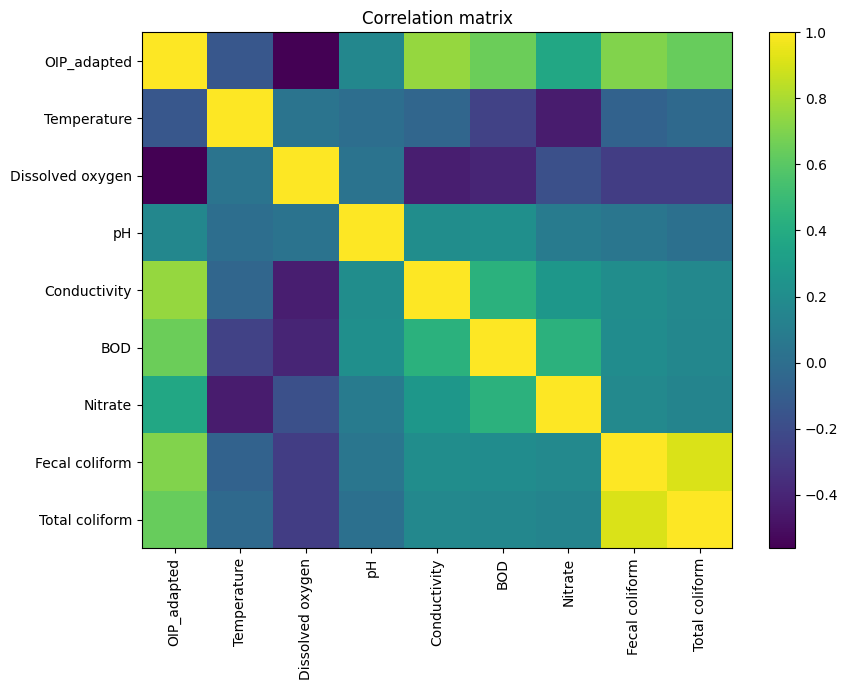

In [15]:
print_section("6. India exploratory summaries")
india_correlation_matrix = india_scored_df[["oip_adapted", *MODEL_FEATURES]].corr(numeric_only=True).round(6)

fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(india_correlation_matrix, aspect="auto")
heatmap_labels = [
    "OIP_adapted" if column == "oip_adapted" else PAPER_LABELS.get(column, column)
    for column in india_correlation_matrix.columns
]
ax.set_xticks(range(len(heatmap_labels)))
ax.set_xticklabels(heatmap_labels, rotation=90)
ax.set_yticks(range(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels)
ax.set_title("Correlation matrix")
fig.colorbar(heatmap)
display_figure(fig)


**What this shows:** The heatmap summarizes the correlation structure between the adapted OIP and the eight India modeling features.

**What to notice:** Dissolved oxygen is the strongest inverse correlate (-0.562), while conductivity (0.756), BOD (0.648), and nitrate (0.372) move positively with pollution severity.

**Why it matters:** The directions are environmentally plausible, which supports the adapted OIP as a defensible pollution representation rather than an arbitrary aggregation.


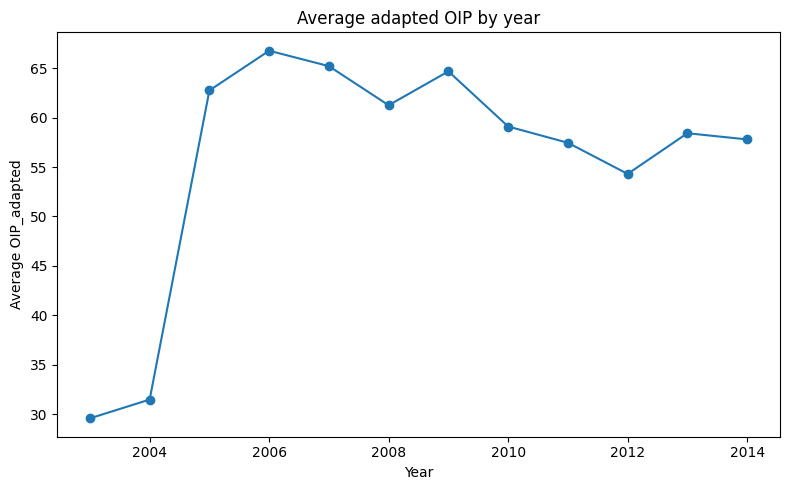

In [16]:
india_yearly_oip = india_scored_df.groupby(YEAR, as_index=False)["oip_adapted"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(india_yearly_oip[YEAR], india_yearly_oip["oip_adapted"], marker="o")
ax.set_title("Average adapted OIP by year")
ax.set_xlabel("Year")
ax.set_ylabel("Average OIP_adapted")
display_figure(fig)


**What this shows:** This plot tracks the mean India adapted OIP from 2003 to 2014.

**What to notice:** The yearly average rises from 29.603 in 2003 to 57.789 in 2014, showing substantial descriptive variation across the analytical sample.

**Why it matters:** The pattern is a useful check on temporal variation, but it should still be read descriptively because yearly sample composition can also change.


In [17]:
india_model_frame = prepare_model_feature_frame(india_scored_df)
india_scaled_features = StandardScaler().fit_transform(india_model_frame)
india_clusters = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit_predict(
    india_scaled_features
)
india_clustered_df = india_scored_df.copy()
india_clustered_df["cluster"] = india_clusters
india_silhouette_score = float(silhouette_score(india_scaled_features, india_clusters))


preview_frame(
    "India yearly adapted OIP",
    india_yearly_oip.round(4),
    rows=len(india_yearly_oip),
)


India yearly adapted OIP
------------------------
  year  oip_adapted
2003.0      29.6029
2004.0      31.4998
2005.0      62.7362
2006.0      66.7527
2007.0      65.1938
2008.0      61.2414
2009.0      64.6674
2010.0      59.0939
2011.0      57.4484
2012.0      54.3029
2013.0      58.4149
2014.0      57.7892



**What this shows:** This table gives the exact yearly averages behind the India trend plot.

**What to notice:** It makes the temporal movement explicit year by year, from 29.603 in 2003 to 57.789 in 2014.

**Why it matters:** Seeing the values directly helps separate a broad descriptive shift from stronger claims about causes or mechanisms.


In [18]:
print(f"India silhouette score: {india_silhouette_score:.4f}")

India silhouette score: 0.2079



**What this shows:** The silhouette score of 0.2079 summarizes how separated the India clusters are in feature space.

**What to notice:** The value is positive but modest, so the severity structure is meaningful without implying sharply discrete natural classes.

**Why it matters:** This supports the adapted OIP labels as an internally coherent analytical representation while keeping the interpretation appropriately cautious.



## 7. India supervised benchmark across the seven classifiers

The benchmark uses the canonical eight-feature frame, applies `log1p` to the two coliform variables, and evaluates seven candidate classifiers with stratified 5-fold cross-validation.



7. India supervised benchmark across the seven classifiers


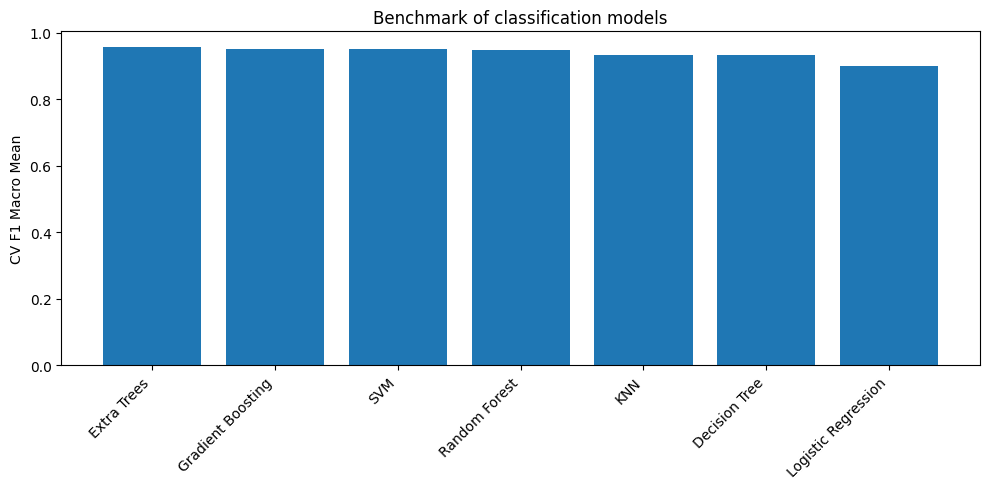

In [19]:
print_section("7. India supervised benchmark across the seven classifiers")
india_label_encoder = LabelEncoder()
india_target = india_label_encoder.fit_transform(india_clustered_df["pollution_level"])
india_stratify_target = india_target if pd.Series(india_target).value_counts().min() >= 2 else None
india_x_train, india_x_test, india_y_train, india_y_test = train_test_split(
    india_model_frame,
    india_target,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=india_stratify_target,
)
india_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
india_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}
india_models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "KNN": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
        ]
    ),
    "Random Forest": Pipeline(
        [
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_estimators=300,
                    class_weight="balanced",
                    n_jobs=1,
                ),
            ),
        ]
    ),
    "Extra Trees": Pipeline(
        [
            (
                "model",
                ExtraTreesClassifier(
                    random_state=RANDOM_STATE,
                    n_estimators=300,
                    class_weight="balanced",
                    n_jobs=1,
                ),
            ),
        ]
    ),
    "SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=RANDOM_STATE, class_weight="balanced")),
        ]
    ),
    "Gradient Boosting": Pipeline(
        [("model", GradientBoostingClassifier(random_state=RANDOM_STATE))]
    ),
}

india_benchmark_rows: list[dict[str, float | str]] = []
for model_name, model in india_models.items():
    cv_scores = cross_validate(
        model,
        india_model_frame,
        india_target,
        cv=india_cv,
        scoring=india_scoring,
        n_jobs=1,
    )
    india_benchmark_rows.append(
        {
            "Model": model_name,
            "CV Accuracy Mean": float(np.mean(cv_scores["test_accuracy"])),
            "CV Balanced Accuracy Mean": float(np.mean(cv_scores["test_balanced_accuracy"])),
            "CV F1 Macro Mean": float(np.mean(cv_scores["test_f1_macro"])),
            "CV Precision Macro Mean": float(np.mean(cv_scores["test_precision_macro"])),
            "CV Recall Macro Mean": float(np.mean(cv_scores["test_recall_macro"])),
        }
    )

india_benchmark_df = pd.DataFrame(india_benchmark_rows).sort_values(
    "CV F1 Macro Mean",
    ascending=False,
).reset_index(drop=True)
india_best_cv_row = india_benchmark_df.iloc[0]
india_svm_cv_f1 = float(
    india_benchmark_df.loc[india_benchmark_df["Model"] == "SVM", "CV F1 Macro Mean"].iloc[0]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(india_benchmark_df["Model"], india_benchmark_df["CV F1 Macro Mean"])
ax.set_ylabel("CV F1 Macro Mean")
ax.set_title("Benchmark of classification models")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
display_figure(fig)


**What this shows:** This plot compares cross-validated macro-F1 across the seven India candidate classifiers.

**What to notice:** Extra Trees leads the benchmark at 0.9571, while SVM remains highly competitive at 0.9505; the strongest models are clustered near the top.

**Why it matters:** Benchmarking multiple model families first clarifies which candidates are strong enough to justify targeted tuning.


In [20]:
preview_frame(
    "India cross-validated benchmark",
    india_benchmark_df[
        [
            "Model",
            "CV Accuracy Mean",
            "CV Balanced Accuracy Mean",
            "CV F1 Macro Mean",
        ]
    ].round(4),
    rows=len(india_benchmark_df),
)


India cross-validated benchmark
-------------------------------
              Model  CV Accuracy Mean  CV Balanced Accuracy Mean  CV F1 Macro Mean
        Extra Trees            0.9593                     0.9501            0.9571
  Gradient Boosting            0.9578                     0.9441            0.9522
                SVM            0.9568                     0.9579            0.9505
      Random Forest            0.9558                     0.9416            0.9501
                KNN            0.9362                     0.9330            0.9349
      Decision Tree            0.9357                     0.9362            0.9341
Logistic Regression            0.9081                     0.9164            0.8999



**What this shows:** This table gives the main cross-validated benchmark metrics for the seven India classifiers.

**What to notice:** Extra Trees has the strongest cross-validated macro-F1, but the top candidates are close enough to justify tuning both ensemble and kernel models.

**Why it matters:** The held-out selection that follows is easier to interpret when it is grounded in a broader benchmark rather than a single model family.



## 8. India tuning of Random Forest, Extra Trees, and SVM

This section tunes the three strongest candidates from the initial benchmark and uses macro-F1 under the same stratified 5-fold CV setup as the optimization target.


In [21]:
print_section("8. India tuning of Random Forest, Extra Trees, and SVM")
rf_grid = GridSearchCV(
    estimator=Pipeline(
        [
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=1,
                ),
            )
        ]
    ),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    },
    cv=india_cv,
    scoring="f1_macro",
    n_jobs=1,
)
rf_grid.fit(india_x_train, india_y_train)

et_grid = GridSearchCV(
    estimator=Pipeline(
        [
            (
                "model",
                ExtraTreesClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=1,
                ),
            )
        ]
    ),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    },
    cv=india_cv,
    scoring="f1_macro",
    n_jobs=1,
)
et_grid.fit(india_x_train, india_y_train)

svm_grid = GridSearchCV(
    estimator=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=RANDOM_STATE, class_weight="balanced")),
        ]
    ),
    param_grid={
        "model__C": [0.5, 1, 5],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"],
    },
    cv=india_cv,
    scoring="f1_macro",
    n_jobs=1,
)
svm_grid.fit(india_x_train, india_y_train)

india_tuned_models = {
    "Random Forest": rf_grid.best_estimator_,
    "Extra Trees": et_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
}
india_tuning_summary = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Best CV F1 Macro": float(rf_grid.best_score_),
            "Best Params": str(rf_grid.best_params_),
        },
        {
            "Model": "Extra Trees",
            "Best CV F1 Macro": float(et_grid.best_score_),
            "Best Params": str(et_grid.best_params_),
        },
        {
            "Model": "SVM",
            "Best CV F1 Macro": float(svm_grid.best_score_),
            "Best Params": str(svm_grid.best_params_),
        },
    ]
).sort_values("Best CV F1 Macro", ascending=False)
india_best_tuned_row = india_tuning_summary.iloc[0]

preview_frame(
    "India tuning summary",
    india_tuning_summary.round({"Best CV F1 Macro": 4}),
    rows=len(india_tuning_summary),
)


8. India tuning of Random Forest, Extra Trees, and SVM

India tuning summary
--------------------
        Model  Best CV F1 Macro                                                                                                       Best Params
          SVM            0.9632                                                  {'model__C': 5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Extra Trees            0.9538 {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Random Forest            0.9498 {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}



**What this shows:** This table reports the best macro-F1 found when tuning Random Forest, Extra Trees, and SVM.

**What to notice:** SVM reaches the strongest tuned result here at 0.9632 after targeted search over its main hyperparameters.

**Why it matters:** Focused tuning tests whether the strongest benchmark models improve enough to change the final reusable classifier choice.



## 9. India held-out evaluation and final reusable classifier selection

All tuned candidates are evaluated on the held-out split. After that comparison, the code retains `SVM` as the reusable classifier used in the later transfer stage.



9. India held-out evaluation and final reusable classifier selection


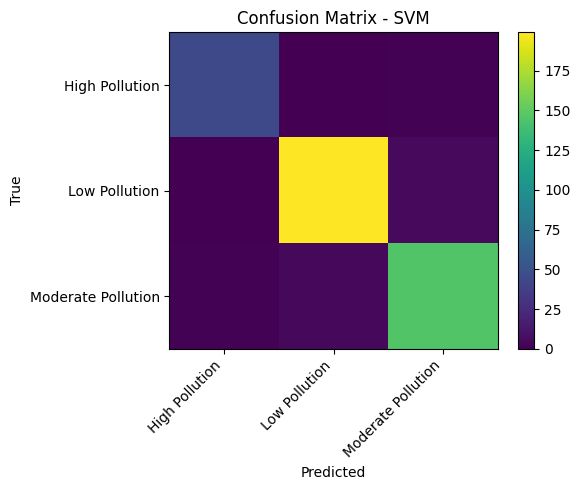

In [22]:
print_section("9. India held-out evaluation and final reusable classifier selection")
india_test_rows: list[dict[str, float | str]] = []
for model_name, model in india_tuned_models.items():
    model.fit(india_x_train, india_y_train)
    predictions = model.predict(india_x_test)
    india_test_rows.append(
        {
            "Model": model_name,
            "Test Accuracy": accuracy_score(india_y_test, predictions),
            "Test Balanced Accuracy": balanced_accuracy_score(india_y_test, predictions),
            "Test F1 Macro": f1_score(india_y_test, predictions, average="macro"),
            "Test Precision Macro": precision_score(
                india_y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
            "Test Recall Macro": recall_score(
                india_y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
        }
    )

india_test_results_df = pd.DataFrame(india_test_rows).sort_values(
    "Test F1 Macro",
    ascending=False,
).reset_index(drop=True)
india_accuracy_leader = india_test_results_df.sort_values("Test Accuracy", ascending=False).iloc[0]
india_top_model_name = str(india_test_results_df.iloc[0]["Model"])
india_selected_classifier_name = "SVM"
india_selected_classifier = india_tuned_models[india_selected_classifier_name]
india_selected_classifier.fit(india_x_train, india_y_train)
india_selected_predictions = india_selected_classifier.predict(india_x_test)
india_classification_report_df = (
    pd.DataFrame(
        classification_report(
            india_y_test,
            india_selected_predictions,
            target_names=india_label_encoder.classes_,
            output_dict=True,
            zero_division=0,
        )
    )
    .T.reset_index()
    .rename(columns={"index": "label"})
)
india_confusion_matrix = confusion_matrix(india_y_test, india_selected_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(india_confusion_matrix, aspect="auto")
ax.set_title(f"Confusion Matrix - {india_selected_classifier_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(india_label_encoder.classes_)))
ax.set_xticklabels(india_label_encoder.classes_, rotation=45, ha="right")
ax.set_yticks(range(len(india_label_encoder.classes_)))
ax.set_yticklabels(india_label_encoder.classes_)
fig.colorbar(image)
display_figure(fig)


**What this shows:** This confusion matrix shows how the selected India classifier (`SVM`) behaves on the held-out reference split.

**What to notice:** Most residual errors fall between adjacent severity levels rather than between the lowest and highest observed classes, which is what we expect for an ordered pollution taxonomy.

**Why it matters:** That error pattern supports the internal consistency of the India labels and shows that the selected classifier is mostly making near-boundary mistakes rather than arbitrary jumps.


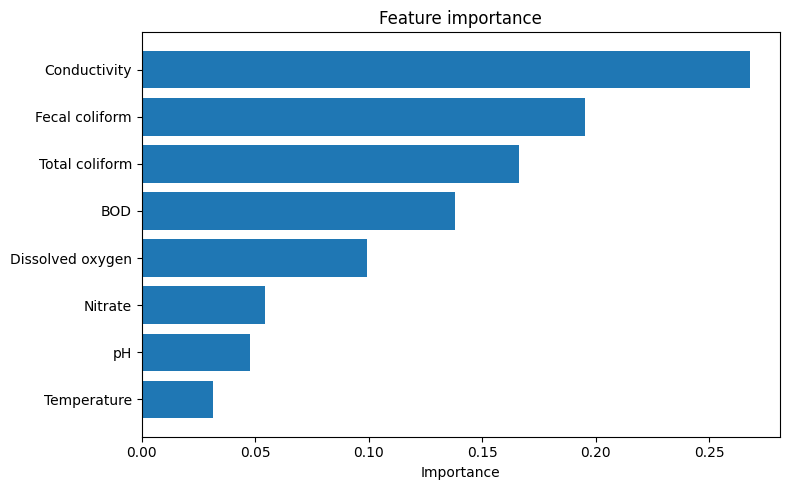

In [23]:
if india_selected_classifier_name == "Extra Trees":
    india_importance_model = india_tuned_models["Extra Trees"]
    india_importance_note = "Feature importance extracted from Extra Trees."
else:
    india_importance_model = india_tuned_models["Random Forest"]
    india_importance_note = (
        "Feature importance extracted from Random Forest because the selected "
        "reusable classifier does not expose native tree importances."
    )

india_importance_model.fit(india_x_train, india_y_train)
india_tree_estimator = india_importance_model.named_steps["model"]
india_importances = pd.Series(
    india_tree_estimator.feature_importances_,
    index=india_model_frame.columns,
).sort_values(ascending=False)
india_feature_importance_df = pd.DataFrame(
    {
        "Rank": range(1, len(india_importances) + 1),
        "Feature": [paper_feature_name(feature) for feature in india_importances.index],
        "Importance": india_importances.values,
    }
)
india_top_importance_features = ", ".join(india_feature_importance_df["Feature"].head(5).tolist())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    [paper_feature_name(feature) for feature in india_importances.index[::-1]],
    india_importances.values[::-1],
)
ax.set_title("Feature importance")
ax.set_xlabel("Importance")
display_figure(fig)


**What this shows:** This plot ranks the tree-based feature importances used for interpretability in the India analysis.

**What to notice:** The leading signals are Conductivity, Fecal coliform, Total coliform, BOD, and Dissolved oxygen, so ionic load and microbiological contamination dominate the importance profile alongside organic load and oxygen depletion.

**Why it matters:** That ranking is environmentally plausible and helps explain which measurements drive the recovered class structure most strongly.


In [24]:
india_final_benchmark_df = india_benchmark_df.merge(india_test_results_df, on="Model", how="left")
preview_frame(
    "India held-out test results",
    india_test_results_df[
        ["Model", "Test Accuracy", "Test Balanced Accuracy", "Test F1 Macro"]
    ].round(4),
    rows=len(india_test_results_df),
)


India held-out test results
---------------------------
        Model  Test Accuracy  Test Balanced Accuracy  Test F1 Macro
          SVM         0.9724                  0.9733         0.9730
  Extra Trees         0.9749                  0.9686         0.9719
Random Forest         0.9699                  0.9647         0.9680



**What this shows:** This table compares the tuned India candidates on the held-out reference split.

**What to notice:** SVM is best on macro-F1, while Extra Trees has the highest raw accuracy at 0.9749.

**Why it matters:** That tradeoff matters because macro-F1 and balanced accuracy are more informative than raw accuracy when performance needs to remain strong across all observed severity levels.


In [25]:
print(f"Held-out top model by macro-F1: {india_top_model_name}")
print(f"Canonical reusable classifier: {india_selected_classifier_name}")
print(f"Top India importance signals: {india_top_importance_features}")
print(india_importance_note)

Held-out top model by macro-F1: SVM
Canonical reusable classifier: SVM
Top India importance signals: Conductivity, Fecal coliform, Total coliform, BOD, Dissolved oxygen
Feature importance extracted from Random Forest because the selected reusable classifier does not expose native tree importances.



**What this shows:** The held-out comparison is followed by an explicit selection step that keeps `SVM` as the reusable classifier for transfer scoring.

**What to notice:** `SVM` leads this run on macro-F1 and balanced accuracy, while the tree-based importance analysis is taken from a separate `RandomForestClassifier` because `SVM` does not expose native feature importances.

**Why it matters:** This keeps predictive selection and interpretability separate: one model is reused for classification, and another is used to explain the feature ranking.



## 10. India surrogate Random Forest regression and continuous-score agreement

This section trains a Random Forest regressor to approximate the continuous adapted OIP score and evaluates how closely the learned `ml_wqi` matches the rule-based score on India data.



10. India surrogate Random Forest regression and continuous-score agreement


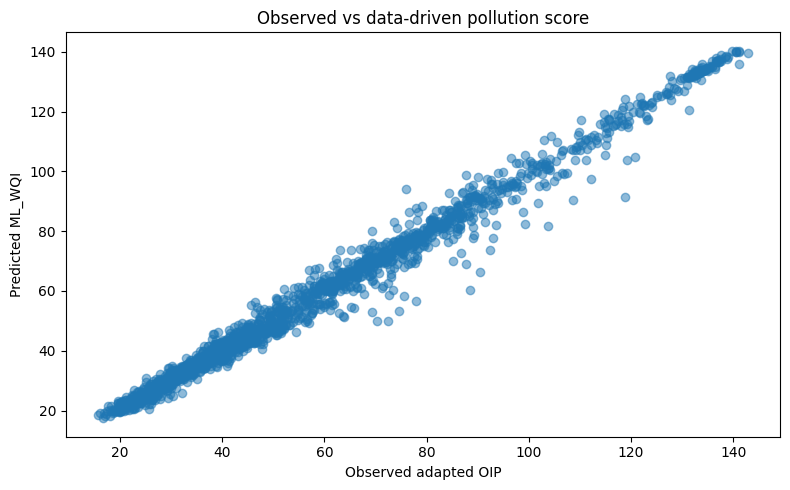

In [26]:
print_section("10. India surrogate Random Forest regression and continuous-score agreement")
india_surrogate_target = india_clustered_df["oip_adapted"].copy()
india_regression_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
india_surrogate_regressor = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_STATE,
    max_depth=None,
    n_jobs=1,
)
india_surrogate_predicted = cross_val_predict(
    india_surrogate_regressor,
    india_model_frame,
    india_surrogate_target,
    cv=india_regression_cv,
    n_jobs=1,
)
india_enriched_df = india_clustered_df.copy()
india_enriched_df["ml_wqi"] = india_surrogate_predicted
india_surrogate_r2 = float(r2_score(india_surrogate_target, india_surrogate_predicted))
india_surrogate_mae = float(mean_absolute_error(india_surrogate_target, india_surrogate_predicted))
india_surrogate_corr = float(
    india_enriched_df[["oip_adapted", "ml_wqi"]].corr().iloc[0, 1]
)
india_surrogate_metrics = pd.DataFrame(
    {
        "Metric": [
            "R2 between observed adapted OIP and ML_WQI",
            "MAE between observed adapted OIP and ML_WQI",
            "Correlation between observed adapted OIP and ML_WQI",
        ],
        "Value": [india_surrogate_r2, india_surrogate_mae, india_surrogate_corr],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(india_enriched_df["oip_adapted"], india_enriched_df["ml_wqi"], alpha=0.5)
ax.set_xlabel("Observed adapted OIP")
ax.set_ylabel("Predicted ML_WQI")
ax.set_title("Observed vs data-driven pollution score")
display_figure(fig)


**What this shows:** This scatter compares observed India adapted OIP values with cross-validated `ML_WQI` predictions from the Random Forest surrogate.

**What to notice:** The points cluster tightly around the diagonal, consistent with `R2 = 0.9872` and correlation `= 0.9936`.

**Why it matters:** The surrogate recovers the continuous India pollution signal with very high fidelity, which makes it useful for the later transfer stage.


In [27]:
preview_frame(
    "India surrogate metrics",
    india_surrogate_metrics.round(4),
    rows=len(india_surrogate_metrics),
)


India surrogate metrics
-----------------------
                                             Metric  Value
         R2 between observed adapted OIP and ML_WQI 0.9872
        MAE between observed adapted OIP and ML_WQI 2.1603
Correlation between observed adapted OIP and ML_WQI 0.9936



**What this shows:** This table summarizes agreement between the India rule-based adapted OIP and the learned `ML_WQI` proxy.

**What to notice:** `R2 = 0.9872`, `MAE = 2.1603`, and correlation `= 0.9936`, so the surrogate reproduces the India score with very limited error.

**Why it matters:** The regressor is best understood as a high-fidelity learned proxy for the India score over this measurement space.



## 11. India reusable in-memory models

This section refits the selected India classifier and the surrogate regressor on the full India feature frame, keeps both fitted objects in memory, and bundles them with the label encoder for the Mexico stage.


In [28]:
print_section("11. India reusable in-memory models")

india_full_label_encoder = LabelEncoder()
india_full_target = india_full_label_encoder.fit_transform(india_enriched_df["pollution_level"])
india_full_model_frame = prepare_model_feature_frame(india_enriched_df)

india_exported_classifier = clone(india_tuned_models["SVM"])
india_exported_classifier.fit(india_full_model_frame, india_full_target)

india_exported_surrogate = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_STATE,
    max_depth=None,
    n_jobs=1,
)
india_exported_surrogate.fit(india_full_model_frame, india_enriched_df["oip_adapted"])
print("Reusable models retained in memory for the Mexico transfer stage.")
print(f"Classifier: {india_selected_classifier_name}")
print(f"Surrogate model: Random Forest regressor")

india_transfer_bundle = {
    "classifier": india_exported_classifier,
    "surrogate": india_exported_surrogate,
    "label_encoder": india_full_label_encoder,
}


11. India reusable in-memory models
Reusable models retained in memory for the Mexico transfer stage.
Classifier: SVM
Surrogate model: Random Forest regressor



## 12. Mexico workbook load and tidy join

The Mexico stage starts by loading the workbook sheets `Sitios`, `Resultados`, and `Simbología`. The code then joins site metadata into the row-level measurements to create a single tidy table for harmonization.


In [29]:
print_section("12. Mexico workbook load and tidy join")
mexico_workbook = load_mexico_workbook(MEXICO_RAW_WORKBOOK)
mexico_tidy_df = build_tidy_dataset(mexico_workbook)
preview_frame(
    "Mexico workbook summary",
    mexico_workbook.workbook_summary,
    rows=len(mexico_workbook.workbook_summary),
)
mexico_resultados_rows = int(
    mexico_workbook.workbook_summary.loc[
        mexico_workbook.workbook_summary["Sheet"] == "Resultados",
        "Rows",
    ].iloc[0]
)


12. Mexico workbook load and tidy join

Mexico workbook summary
-----------------------
     Sheet  Rows  Columns
    Sitios  2700       12
Resultados 75435      441
Simbología   435        3



**What this shows:** This summary lists the three workbook sheets used in the Mexico analysis.

**What to notice:** `Resultados` is the large analytical table with 75435 rows, while `Sitios` provides site metadata and `Simbología` provides parameter and unit definitions.

**Why it matters:** The later harmonization step depends on combining these pieces into one row-level dataset.


In [30]:
preview_frame(
    "Mexico tidy preview",
    mexico_tidy_df,
    columns=[
        column
        for column in [
            COL_SITE_KEY,
            COL_SITE_NAME,
            COL_DATE,
            COL_YEAR_SOURCE,
            "TEMP_AGUA",
            "OD_mg/L",
            "pH_CAMPO",
            "CONDUC_CAMPO",
            "DBO_TOT",
            "N_NO3-N_NO2",
            "COLI_FEC",
            "COLI_TOT",
        ]
        if column in mexico_tidy_df.columns
    ],
)


Mexico tidy preview
-------------------
CLAVE SITIO                                         NOMBRE DEL SITIO   FECHA REALIZACIÓN  Año  TEMP_AGUA OD_mg/L  pH_CAMPO CONDUC_CAMPO DBO_TOT N_NO3-N_NO2 COLI_FEC COLI_TOT
  CARMINA 2                                                CARMINA 2 2022-11-08 00:00:00 2022       23.0    8.13      7.80          916      <2        <NA>     1076     <NA>
  DLAGU10M1              INDUSTRIAS DEL INTERIOR, S. DE R.L. DE C.V. 2013-01-02 00:00:00 2013       17.3    2.55      8.73         4220    2.59        <NA>       <3       <3
  DLAGU10M1              INDUSTRIAS DEL INTERIOR, S. DE R.L. DE C.V. 2013-01-14 00:00:00 2013       17.3    2.55      8.73         4220    24.5        <NA>       <3       <3
  DLAGU10M1              INDUSTRIAS DEL INTERIOR, S. DE R.L. DE C.V. 2013-01-14 00:00:00 2013       17.7    3.75      8.28         3940    3.21        <NA>       <3       <3
    DLAGU20 DESARROLLOS INDUSTRIALES DE AGUASCALIENTES (AGUAS ABAJO) 2012-12-16 00:00:00 


**What this shows:** This is the joined Mexico row-level analysis table after merging `Resultados` with `Sitios` metadata.

**What to notice:** It is still a raw monitoring view: the workbook field names are intact, censor symbols have not yet been parsed, and the canonical feature schema has not yet been enforced.

**Why it matters:** Keeping this intermediate table visible makes it easier to distinguish direct workbook content from later harmonized analytical fields.



## 13. Mexico harmonization into the India schema

This section performs the schema alignment needed for transfer scoring:

- parse censored numeric values with `<x -> x/2` and `>x -> x`
- select the primary or fallback source for each canonical feature
- exclude incompatible alternate variables from transfer scoring
- preserve missingness after cleaning so scoreable-row counts reflect real coverage


In [31]:
print_section("13. Mexico harmonization into the India schema")
mexico_unique_source_fields: list[str] = []
for mapping in MEXICO_FEATURE_MAPPINGS:
    for column in [mapping.primary_field, *mapping.fallback_fields, *mapping.excluded_fields]:
        if column not in mexico_unique_source_fields:
            mexico_unique_source_fields.append(column)

mexico_numeric_parse_fields = [
    *[column for column in mexico_unique_source_fields if column in mexico_tidy_df.columns],
    *[
        column
        for column in [COL_LATITUDE, COL_LONGITUDE, COL_YEAR_SOURCE]
        if column in mexico_tidy_df.columns
    ],
]
mexico_available_metadata = [
    column for column in MODEL_METADATA_FIELDS if column in mexico_tidy_df.columns
]
mexico_aligned_df = mexico_tidy_df[
    mexico_available_metadata
    + [column for column in mexico_unique_source_fields if column in mexico_tidy_df.columns]
].copy()

mexico_censoring_rows: list[dict[str, object]] = []
for column in mexico_numeric_parse_fields:
    parsed_values, parsed_report = parse_censored_numeric_series(mexico_aligned_df[column])
    mexico_aligned_df[column] = parsed_values
    mexico_censoring_rows.append(
        {
            "variable": column,
            "lt_count": parsed_report["lt_count"],
            "gt_count": parsed_report["gt_count"],
            "total_censored": parsed_report["total_censored"],
            "parsed_non_null": parsed_report["parsed_non_null"],
            "lt_policy": "<x -> x/2",
            "gt_policy": ">x -> x",
        }
    )

mexico_censoring_report = pd.DataFrame(mexico_censoring_rows).sort_values(
    ["total_censored", "variable"],
    ascending=[False, True],
)

if COL_DATE in mexico_aligned_df.columns:
    mexico_parsed_dates = pd.to_datetime(mexico_aligned_df[COL_DATE], errors="coerce")
else:
    mexico_parsed_dates = pd.Series(pd.NaT, index=mexico_aligned_df.index)

if COL_YEAR_SOURCE in mexico_aligned_df.columns:
    mexico_year_numeric = pd.to_numeric(mexico_aligned_df[COL_YEAR_SOURCE], errors="coerce")
else:
    mexico_year_numeric = pd.Series(np.nan, index=mexico_aligned_df.index)
mexico_aligned_df[YEAR] = mexico_year_numeric.fillna(mexico_parsed_dates.dt.year)

mexico_preclean_features = pd.DataFrame(index=mexico_aligned_df.index)
mexico_feature_match_rows: list[dict[str, object]] = []
mexico_unit_map = build_symbol_unit_map(mexico_workbook.simbologia)

for mapping in MEXICO_FEATURE_MAPPINGS:
    candidate_order = [mapping.primary_field, *mapping.fallback_fields]
    selected_values, selected_lineage = select_first_available(
        mexico_aligned_df,
        candidate_order,
    )
    mexico_aligned_df[mapping.canonical_feature] = selected_values
    mexico_aligned_df[mapping.lineage_column] = selected_lineage
    mexico_preclean_features[mapping.canonical_feature] = selected_values

    fallback_rows_used = int(
        selected_lineage.notna().sum() - (selected_lineage == mapping.primary_field).sum()
    )
    primary_exists = mapping.primary_field in mexico_tidy_df.columns
    fallback_exists = any(column in mexico_tidy_df.columns for column in mapping.fallback_fields)
    if fallback_rows_used > 0 and (primary_exists or fallback_exists):
        compatibility = "compatible-with-fallback"
    elif primary_exists:
        compatibility = "exact-compatible"
    elif fallback_exists:
        compatibility = "compatible-with-fallback"
    else:
        compatibility = "incompatible"

    mexico_feature_match_rows.append(
        {
            "India feature": paper_feature_name(mapping.canonical_feature),
            "Mexico source fields": ", ".join(
                field for field in [mapping.primary_field, *mapping.fallback_fields] if field
            ),
            "Compatibility": compatibility,
            "Mexico unit": mexico_unit_map.get(mapping.primary_field, ""),
            "Fallback rows used": fallback_rows_used,
            "Excluded variants": ", ".join(mapping.excluded_fields) if mapping.excluded_fields else "None",
            "Notes": mapping.notes,
        }
    )

mexico_year_source_rows = (
    int(pd.to_numeric(mexico_aligned_df[COL_YEAR_SOURCE], errors="coerce").notna().sum())
    if COL_YEAR_SOURCE in mexico_aligned_df.columns
    else 0
)
mexico_year_fallback_rows = int(mexico_aligned_df[YEAR].notna().sum() - mexico_year_source_rows)
mexico_feature_match_rows.append(
    {
        "India feature": "Year",
        "Mexico source fields": ", ".join(
            column for column in [COL_YEAR_SOURCE, COL_DATE] if column in mexico_tidy_df.columns
        ),
        "Compatibility": "exact-compatible" if mexico_year_source_rows > 0 else "compatible-with-fallback",
        "Mexico unit": "calendar year",
        "Fallback rows used": max(mexico_year_fallback_rows, 0),
        "Excluded variants": "None",
        "Notes": "Year is aligned for descriptive summaries and yearly comparisons.",
    }
)
mexico_feature_match_report = pd.DataFrame(mexico_feature_match_rows)

mexico_scoring_base = pd.DataFrame(index=mexico_aligned_df.index)
mexico_scoring_base[STATE] = mexico_aligned_df.get(
    COL_STATE,
    pd.Series(pd.NA, index=mexico_aligned_df.index),
)
mexico_scoring_base[LOCATION] = mexico_aligned_df.get(
    COL_SITE_NAME,
    pd.Series(pd.NA, index=mexico_aligned_df.index),
)
mexico_scoring_base[YEAR] = mexico_aligned_df[YEAR]
for feature in MODEL_FEATURES:
    mexico_scoring_base[feature] = mexico_aligned_df[feature]

mexico_cleaning = clean_analytical_frame(
    mexico_scoring_base,
    numeric_columns=[*MODEL_FEATURES, YEAR],
    fill_unknown_state=False,
    state_column=STATE,
)
mexico_cleaned_for_scoring = mexico_cleaning.clean_df.copy()
for feature in MODEL_FEATURES:
    mexico_aligned_df[feature] = mexico_cleaned_for_scoring[feature]
mexico_aligned_df[YEAR] = mexico_cleaned_for_scoring[YEAR]
mexico_aligned_df["oip_scoreable"] = mexico_aligned_df[MEXICO_OIP_FEATURES].notna().all(axis=1)
mexico_aligned_df["transfer_scoreable"] = mexico_aligned_df[list(MODEL_FEATURES)].notna().all(axis=1)

mexico_coverage_rows: list[dict[str, object]] = []
mexico_total_rows = len(mexico_aligned_df)
for mapping in MEXICO_FEATURE_MAPPINGS:
    feature = mapping.canonical_feature
    lineage = mexico_aligned_df[mapping.lineage_column]
    before_non_null = int(mexico_preclean_features[feature].notna().sum())
    after_non_null = int(mexico_aligned_df[feature].notna().sum())
    primary_rows = int((lineage == mapping.primary_field).sum())
    fallback_rows = int(lineage.notna().sum() - primary_rows)
    mexico_coverage_rows.append(
        {
            "canonical_feature": feature,
            "paper_feature": paper_feature_name(feature),
            "primary_field": mapping.primary_field,
            "before_clean_non_null": before_non_null,
            "before_clean_coverage_pct": round(before_non_null / mexico_total_rows * 100, 2),
            "after_clean_non_null": after_non_null,
            "after_clean_coverage_pct": round(after_non_null / mexico_total_rows * 100, 2),
            "primary_source_rows": primary_rows,
            "fallback_source_rows": fallback_rows,
        }
    )
mexico_feature_coverage = pd.DataFrame(mexico_coverage_rows)
mexico_feature_coverage_mean = float(mexico_feature_coverage["after_clean_coverage_pct"].mean())
mexico_top_fallback_row = mexico_feature_coverage.sort_values(
    "fallback_source_rows",
    ascending=False,
).iloc[0]

mexico_keep_columns = [
    *mexico_available_metadata,
    YEAR,
    *[column for column in mexico_unique_source_fields if column in mexico_aligned_df.columns],
    *[mapping.canonical_feature for mapping in MEXICO_FEATURE_MAPPINGS],
    *[mapping.lineage_column for mapping in MEXICO_FEATURE_MAPPINGS],
    "oip_scoreable",
    "transfer_scoreable",
]
mexico_aligned_df = mexico_aligned_df[mexico_keep_columns].copy()

preview_frame(
    "Mexico feature coverage",
    mexico_feature_coverage.round(2),
    rows=len(mexico_feature_coverage),
)


13. Mexico harmonization into the India schema

Mexico feature coverage
-----------------------
canonical_feature    paper_feature primary_field  before_clean_non_null  before_clean_coverage_pct  after_clean_non_null  after_clean_coverage_pct  primary_source_rows  fallback_source_rows
      temperature      Temperature     TEMP_AGUA                  74814                      99.18                 74813                     99.18                71470                  3344
 dissolved_oxygen Dissolved oxygen       OD_mg/L                  72659                      96.32                 72629                     96.28                69208                  3451
               ph               pH      pH_CAMPO                  74917                      99.31                 74917                     99.31                71364                  3553
     conductivity     Conductivity  CONDUC_CAMPO                  74676                      98.99                 73618                     97


**What this shows:** This table summarizes how each canonical feature is recovered from the Mexico workbook after censor parsing and analytical cleaning.

**What to notice:** Average post-clean coverage is 95.62%, and Nitrate relies most heavily on fallback mapping with 73044 rows.

**Why it matters:** Transfer scoring is broadly feasible, but not purely one-to-one; some features depend on controlled fallback selection rather than a single exact source column.


In [32]:
mexico_top_censor_row = mexico_censoring_report.iloc[0]
preview_frame("Mexico censoring report", mexico_censoring_report.round(2))


Mexico censoring report
-----------------------
variable  lt_count  gt_count  total_censored  parsed_non_null lt_policy gt_policy
 DBO_SOL     37148         0           37148            67111 <x -> x/2   >x -> x
COLI_TOT      1846     28321           30167            67487 <x -> x/2   >x -> x
 DBO_TOT     27941         2           27943            70719 <x -> x/2   >x -> x
COLI_FEC      3986     20489           24475            73814 <x -> x/2   >x -> x
   N_NO3     10362        10           10372            73135 <x -> x/2   >x -> x



**What this shows:** This report counts censored Mexico measurements and the deterministic parsing rules applied to them.

**What to notice:** The parser uses `<x -> x/2` and `>x -> x`, and the largest censored burden appears in `DBO_SOL` with 37148 rows.

**Why it matters:** Censor handling materially affects usable coverage because those values would otherwise remain text-like and drop out of the harmonized feature frame.


In [33]:
print(f"Excluded Mexico variants from transfer scoring: {', '.join(EXCLUDED_VARIANTS)}")
print(f"Mexico rows scoreable for adapted OIP: {int(mexico_aligned_df['oip_scoreable'].sum())}")
print(f"Mexico rows scoreable for transfer: {int(mexico_aligned_df['transfer_scoreable'].sum())}")

Excluded Mexico variants from transfer scoring: TEMP_AMB, COLI_FEC_UFC, COLI_TOT_UFC
Mexico rows scoreable for adapted OIP: 60388
Mexico rows scoreable for transfer: 60272



**What this shows:** The harmonization leaves 60388 rows with enough data to compute the Mexico adapted OIP and 60272 rows with all eight model features needed for transfer scoring.

**What to notice:** The excluded variants `TEMP_AMB`, `COLI_FEC_UFC`, and `COLI_TOT_UFC` are left out because they do not preserve the intended measurement meaning or unit basis of the canonical schema.

**Why it matters:** This keeps the agreement analysis limited to measurements that are meaningfully comparable across the two datasets.



## 14. Mexico adapted OIP reference and India-to-Mexico transfer scoring

The Mexico scoring stage produces two parallel views of the harmonized data:

- `oip_adapted_mexico` and `mexico_derived_class`, computed directly from the harmonized measurements
- `india_transfer_predicted_class` and `ml_wqi_transfer`, produced by the India-trained classifier and surrogate


In [34]:
print_section("14. Mexico adapted OIP reference and India-to-Mexico transfer scoring")
# Reuse the in-memory India models prepared in section 11.
mexico_scored_df = mexico_aligned_df.copy()
for subindex_column in ["si_do", "si_ph", "si_cond", "si_bod", "si_nitrate", "si_fecal", "si_total"]:
    mexico_scored_df[subindex_column] = np.nan
mexico_scored_df["oip_adapted_mexico"] = np.nan
mexico_scored_df["mexico_derived_class"] = pd.NA
mexico_scored_df["india_transfer_predicted_class"] = pd.NA
mexico_scored_df["ml_wqi_transfer"] = np.nan
mexico_scored_df["class_agreement"] = pd.NA

mexico_oip_index = mexico_scored_df.index[mexico_scored_df["oip_scoreable"]]
if len(mexico_oip_index) > 0:
    mexico_oip_input = mexico_scored_df.loc[mexico_oip_index, list(MODEL_FEATURES) + [YEAR]].copy()
    mexico_oip_scored = add_adapted_oip_columns(mexico_oip_input)
    mexico_subindex_columns = [
        "si_do",
        "si_ph",
        "si_cond",
        "si_bod",
        "si_nitrate",
        "si_fecal",
        "si_total",
    ]
    mexico_scored_df.loc[mexico_oip_index, mexico_subindex_columns] = mexico_oip_scored[
        mexico_subindex_columns
    ]
    mexico_scored_df.loc[mexico_oip_index, "oip_adapted_mexico"] = mexico_oip_scored["oip_adapted"]
    mexico_scored_df.loc[mexico_oip_index, "mexico_derived_class"] = mexico_oip_scored["pollution_level"]

mexico_transfer_index = mexico_scored_df.index[mexico_scored_df["transfer_scoreable"]]
if len(mexico_transfer_index) > 0:
    mexico_transfer_frame = prepare_model_feature_frame(
        mexico_scored_df.loc[mexico_transfer_index, list(MODEL_FEATURES)]
    )
    mexico_predicted_codes = india_transfer_bundle["classifier"].predict(mexico_transfer_frame)
    mexico_predicted_labels = india_transfer_bundle["label_encoder"].inverse_transform(
        mexico_predicted_codes
    )
    mexico_scored_df.loc[mexico_transfer_index, "india_transfer_predicted_class"] = (
        mexico_predicted_labels
    )
    mexico_scored_df.loc[mexico_transfer_index, "ml_wqi_transfer"] = india_transfer_bundle[
        "surrogate"
    ].predict(mexico_transfer_frame)

    if hasattr(india_transfer_bundle["classifier"], "predict_proba"):
        mexico_probability_matrix = india_transfer_bundle["classifier"].predict_proba(
            mexico_transfer_frame
        )
        mexico_probability_labels = india_transfer_bundle["label_encoder"].inverse_transform(
            india_transfer_bundle["classifier"].classes_
        )
        for probability_index, probability_label in enumerate(mexico_probability_labels):
            probability_column = probability_column_name(probability_label)
            mexico_scored_df[probability_column] = np.nan
            mexico_scored_df.loc[mexico_transfer_index, probability_column] = mexico_probability_matrix[
                :,
                probability_index,
            ]

mexico_comparison_mask = (
    mexico_scored_df["transfer_scoreable"]
    & mexico_scored_df["mexico_derived_class"].notna()
    & mexico_scored_df["india_transfer_predicted_class"].notna()
)
mexico_surrogate_mask = (
    mexico_scored_df["transfer_scoreable"]
    & mexico_scored_df["oip_adapted_mexico"].notna()
    & mexico_scored_df["ml_wqi_transfer"].notna()
)
mexico_scored_df.loc[mexico_comparison_mask, "class_agreement"] = (
    mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"]
    == mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"]
)

mexico_class_distribution_series = (
    mexico_scored_df.loc[
        mexico_scored_df["mexico_derived_class"].notna(),
        "mexico_derived_class",
    ]
    .value_counts()
    .reindex(EXPECTED_POLLUTION_CLASSES)
    .dropna()
)
mexico_class_distribution = pd.DataFrame(
    {
        "Class": mexico_class_distribution_series.index,
        "Count": mexico_class_distribution_series.values.astype(int),
    }
)
if not mexico_class_distribution.empty:
    mexico_class_distribution["Percent"] = (
        mexico_class_distribution["Count"] / mexico_class_distribution["Count"].sum() * 100
    ).round(2)
mexico_reference_dominant_class = (
    mexico_class_distribution.sort_values("Count", ascending=False).iloc[0]
    if not mexico_class_distribution.empty
    else None
)

mexico_predicted_distribution_series = (
    mexico_scored_df.loc[
        mexico_scored_df["india_transfer_predicted_class"].notna(),
        "india_transfer_predicted_class",
    ]
    .value_counts()
    .reindex(EXPECTED_POLLUTION_CLASSES)
    .dropna()
)
mexico_predicted_distribution = pd.DataFrame(
    {
        "Predicted Class": mexico_predicted_distribution_series.index,
        "Count": mexico_predicted_distribution_series.values.astype(int),
    }
)
if not mexico_predicted_distribution.empty:
    mexico_predicted_distribution["Percent"] = (
        mexico_predicted_distribution["Count"] / mexico_predicted_distribution["Count"].sum() * 100
    ).round(2)

mexico_classification_metrics = pd.DataFrame(
    [
        {"Metric": "Compared rows", "Value": int(mexico_comparison_mask.sum())},
        {
            "Metric": "Exact agreement",
            "Value": float(mexico_scored_df.loc[mexico_comparison_mask, "class_agreement"].mean())
            if mexico_comparison_mask.any()
            else np.nan,
        },
        {
            "Metric": "Accuracy",
            "Value": accuracy_score(
                mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"],
                mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"],
            )
            if mexico_comparison_mask.any()
            else np.nan,
        },
        {
            "Metric": "Balanced Accuracy",
            "Value": balanced_accuracy_score(
                mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"],
                mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"],
            )
            if mexico_comparison_mask.any()
            else np.nan,
        },
        {
            "Metric": "Macro F1",
            "Value": f1_score(
                mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"],
                mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"],
                average="macro",
                zero_division=0,
            )
            if mexico_comparison_mask.any()
            else np.nan,
        },
    ]
)

if mexico_surrogate_mask.any():
    mexico_observed_oip = mexico_scored_df.loc[mexico_surrogate_mask, "oip_adapted_mexico"]
    mexico_predicted_oip = mexico_scored_df.loc[mexico_surrogate_mask, "ml_wqi_transfer"]
    mexico_surrogate_corr = float(
        pd.DataFrame({"x": mexico_observed_oip, "y": mexico_predicted_oip}).corr().iloc[0, 1]
    )
    mexico_surrogate_metrics = pd.DataFrame(
        [
            {"Metric": "Compared rows", "Value": int(mexico_surrogate_mask.sum())},
            {"Metric": "R2", "Value": float(r2_score(mexico_observed_oip, mexico_predicted_oip))},
            {
                "Metric": "MAE",
                "Value": float(mean_absolute_error(mexico_observed_oip, mexico_predicted_oip)),
            },
            {"Metric": "Correlation", "Value": mexico_surrogate_corr},
        ]
    )
else:
    mexico_surrogate_metrics = pd.DataFrame(
        [
            {"Metric": "Compared rows", "Value": 0},
            {"Metric": "R2", "Value": np.nan},
            {"Metric": "MAE", "Value": np.nan},
            {"Metric": "Correlation", "Value": np.nan},
        ]
    )

mexico_yearly_summary = (
    mexico_scored_df.loc[
        mexico_surrogate_mask & mexico_scored_df[YEAR].notna(),
        [YEAR, "oip_adapted_mexico", "ml_wqi_transfer"],
    ]
    .groupby(YEAR, as_index=False)
    .agg(
        Mean_OIP_Adapted_Mexico=("oip_adapted_mexico", "mean"),
        Mean_ML_WQI_transfer=("ml_wqi_transfer", "mean"),
        Scoreable_Rows=(YEAR, "size"),
    )
    .sort_values(YEAR)
)

preview_frame(
    "Mexico-derived class distribution",
    mexico_class_distribution,
    rows=len(mexico_class_distribution),
)


14. Mexico adapted OIP reference and India-to-Mexico transfer scoring

Mexico-derived class distribution
---------------------------------
              Class  Count  Percent
      Low Pollution   2861     4.74
 Moderate Pollution  16327    27.04
     High Pollution  38198    63.25
Very High Pollution   3002     4.97



**What this shows:** This table reports the class distribution of the Mexico-derived adapted OIP reference.

**What to notice:** High Pollution dominates the reference distribution at 63.25% of the scored Mexico rows.

**Why it matters:** This distribution defines the class pattern that the transferred India classifier is being compared against.


In [35]:
mexico_transfer_compared_rows = int(metric_value(mexico_classification_metrics, "Compared rows"))
mexico_transfer_accuracy_value = metric_value(mexico_classification_metrics, "Accuracy")
mexico_transfer_balanced_accuracy_value = metric_value(
    mexico_classification_metrics,
    "Balanced Accuracy",
)
mexico_transfer_macro_f1_value = metric_value(mexico_classification_metrics, "Macro F1")
preview_frame(
    "Mexico transfer classification metrics",
    mexico_classification_metrics.round(4),
    rows=len(mexico_classification_metrics),
)


Mexico transfer classification metrics
--------------------------------------
           Metric      Value
    Compared rows 60272.0000
  Exact agreement     0.6710
         Accuracy     0.6710
Balanced Accuracy     0.5936
         Macro F1     0.5528



**What this shows:** This table summarizes agreement between the India-trained classifier and the Mexico-derived reference on 60272 harmonized rows.

**What to notice:** Accuracy is 0.6710, balanced accuracy is 0.5936, and macro-F1 is 0.5528, which indicates partial but nontrivial class transfer agreement.

**Why it matters:** These metrics quantify how much of the Mexico-derived class structure is recovered by the India-trained classifier under the shared harmonized feature space.


In [36]:
mexico_transfer_r2_value = metric_value(mexico_surrogate_metrics, "R2")
mexico_transfer_mae_value = metric_value(mexico_surrogate_metrics, "MAE")
mexico_transfer_corr_value = metric_value(mexico_surrogate_metrics, "Correlation")
preview_frame(
    "Mexico transfer surrogate metrics",
    mexico_surrogate_metrics.round(4),
    rows=len(mexico_surrogate_metrics),
)


Mexico transfer surrogate metrics
---------------------------------
       Metric      Value
Compared rows 60272.0000
           R2     0.2346
          MAE    32.2181
  Correlation     0.9128



**What this shows:** This table compares the India-transferred `ML_WQI` surrogate with the Mexico-derived adapted OIP.

**What to notice:** Correlation reaches 0.9128, but `R2` is only 0.2346 and `MAE` is 32.2181, so ranking agreement is much stronger than score calibration.

**Why it matters:** The transferred surrogate preserves useful relative signal, but its absolute scale shifts on the Mexico data.



## 15. Mexico transfer metrics, class agreement, figures, and yearly summary

This section keeps the Mexico evaluation tables inline and visualizes feature coverage, class agreement, continuous-score agreement, and yearly direct-versus-transfer score trends.



15. Mexico transfer metrics, class agreement, and yearly summary


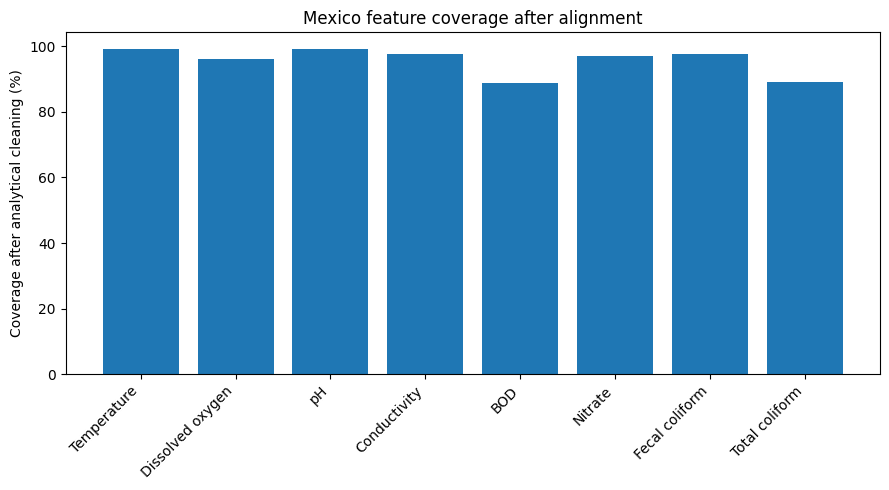

In [37]:
print_section("15. Mexico transfer metrics, class agreement, and yearly summary")
mexico_lowest_coverage_row = mexico_feature_coverage.sort_values(
    "after_clean_coverage_pct",
    ascending=True,
).iloc[0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(mexico_feature_coverage["paper_feature"], mexico_feature_coverage["after_clean_coverage_pct"])
ax.set_ylabel("Coverage after analytical cleaning (%)")
ax.set_title("Mexico feature coverage after alignment")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
display_figure(fig)


**What this shows:** This plot summarizes retained Mexico feature coverage after alignment to the canonical schema.

**What to notice:** Coverage remains broadly high, averaging 95.62% after cleaning, with BOD the lowest retained feature at 88.87%.

**Why it matters:** Broad retained coverage is what makes transfer scoring possible despite fallback mapping, excluded variants, and censored-value handling.


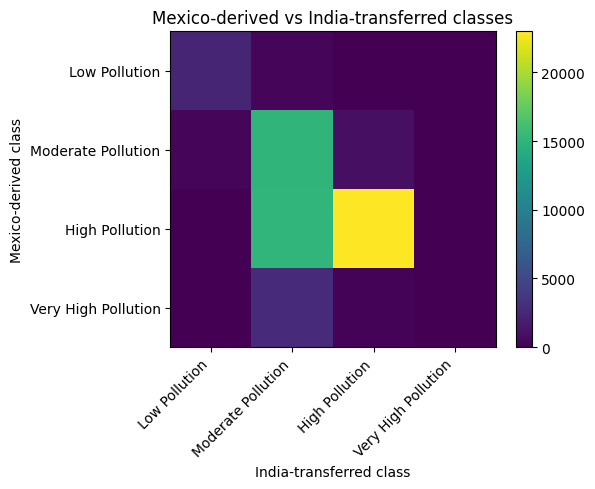

In [38]:
if mexico_comparison_mask.any():
    mexico_present_labels = [
        label
        for label in EXPECTED_POLLUTION_CLASSES
        if (
            (mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"] == label).any()
            or (
                mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"]
                == label
            ).any()
        )
    ]
    mexico_confusion_matrix = confusion_matrix(
        mexico_scored_df.loc[mexico_comparison_mask, "mexico_derived_class"],
        mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"],
        labels=mexico_present_labels,
    )
    mexico_predicts_very_high = (
        mexico_scored_df.loc[mexico_comparison_mask, "india_transfer_predicted_class"]
        == "Very High Pollution"
    ).any()
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(mexico_confusion_matrix, aspect="auto")
    ax.set_title("Mexico-derived vs India-transferred classes")
    ax.set_xlabel("India-transferred class")
    ax.set_ylabel("Mexico-derived class")
    ax.set_xticks(range(len(mexico_present_labels)))
    ax.set_xticklabels(mexico_present_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(mexico_present_labels)))
    ax.set_yticklabels(mexico_present_labels)
    fig.colorbar(image)
    display_figure(fig)
else:
    display_placeholder_figure(
        "Mexico-derived vs India-transferred classes",
        "No rows were available for the class-agreement comparison.",
    )


**What this shows:** This confusion matrix compares the Mexico-derived rule-based classes with the India-transferred class predictions.

**What to notice:** Most of the mass sits in the Moderate and High Pollution ranges, and the India classifier cannot emit Very High Pollution because that class was not observed during India training.

**Why it matters:** The figure makes the class-transfer errors visible and shows where the transferred classifier concentrates its predictions.


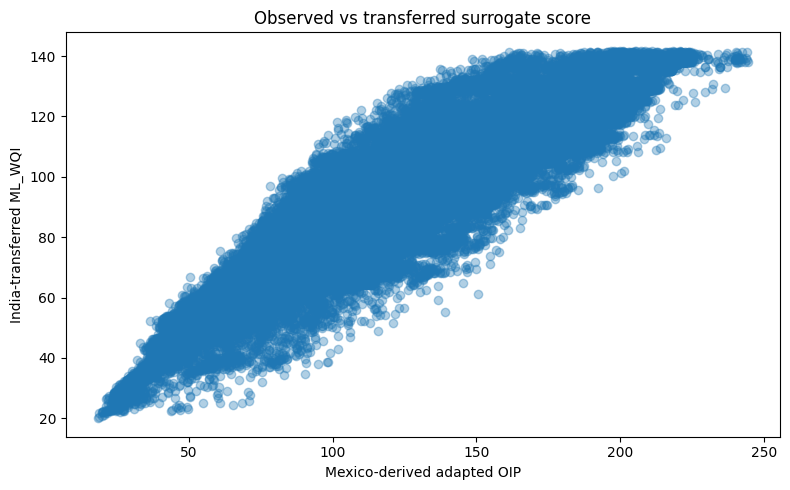

In [39]:
if mexico_surrogate_mask.any():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        mexico_scored_df.loc[mexico_surrogate_mask, "oip_adapted_mexico"],
        mexico_scored_df.loc[mexico_surrogate_mask, "ml_wqi_transfer"],
        alpha=0.35,
    )
    ax.set_xlabel("Mexico-derived adapted OIP")
    ax.set_ylabel("India-transferred ML_WQI")
    ax.set_title("Observed vs transferred surrogate score")
    display_figure(fig)
else:
    display_placeholder_figure(
        "Observed vs transferred surrogate score",
        "No rows were available for surrogate comparison.",
    )

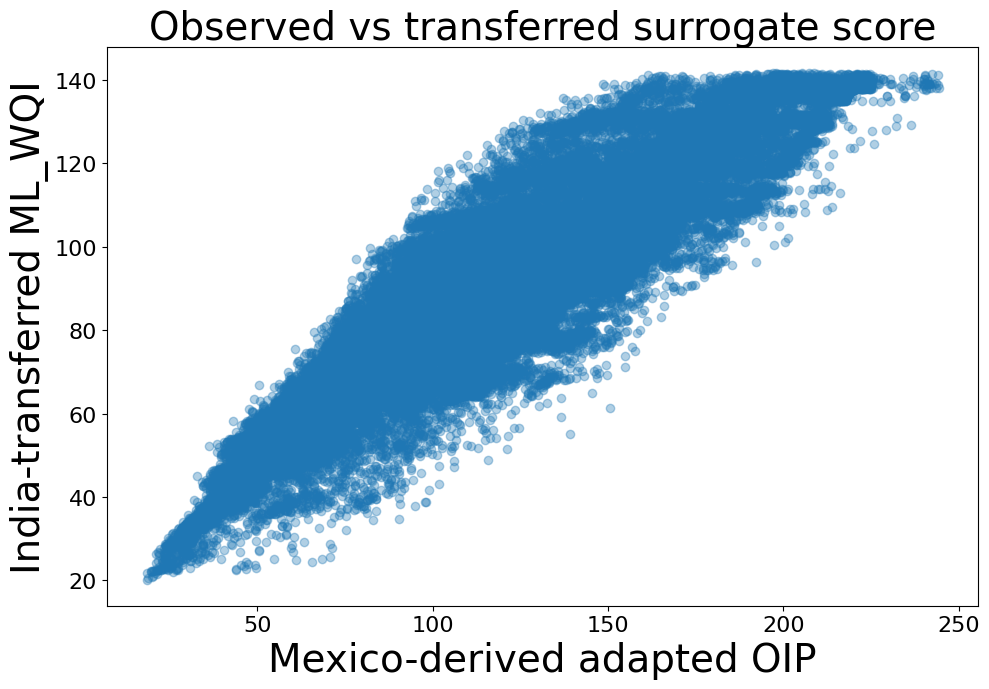

In [40]:
if mexico_surrogate_mask.any():
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        mexico_scored_df.loc[mexico_surrogate_mask, "oip_adapted_mexico"],
        mexico_scored_df.loc[mexico_surrogate_mask, "ml_wqi_transfer"],
        alpha=0.35,
    )

    # Bigger labels and title
    ax.set_xlabel(
        "Mexico-derived adapted OIP",
        fontsize=28
    )

    ax.set_ylabel(
        "India-transferred ML_WQI",
        fontsize=28
    )

    ax.set_title(
        "Observed vs transferred surrogate score",
        fontsize=28
    )

    # Bigger tick labels
    ax.tick_params(axis="both", labelsize=16)

    # Improve layout
    fig.tight_layout()

    # Save figure in high resolution
    fig.savefig(
        "surrogate_scatter.png",
        dpi=300,
        bbox_inches="tight"
    )

    display_figure(fig)

else:
    display_placeholder_figure(
        "Observed vs transferred surrogate score",
        "No rows were available for surrogate comparison.",
    )


**What this shows:** This scatter compares the Mexico-derived adapted OIP with the India-transferred `ML_WQI` surrogate.

**What to notice:** The cloud still shows a strong positive monotonic relation, but the spread away from the ideal diagonal is much wider than in India, consistent with correlation `= 0.9128` and `R2 = 0.2346`.

**Why it matters:** The continuous transfer retains ordering better than calibration, which is the main limitation visible in this comparison.


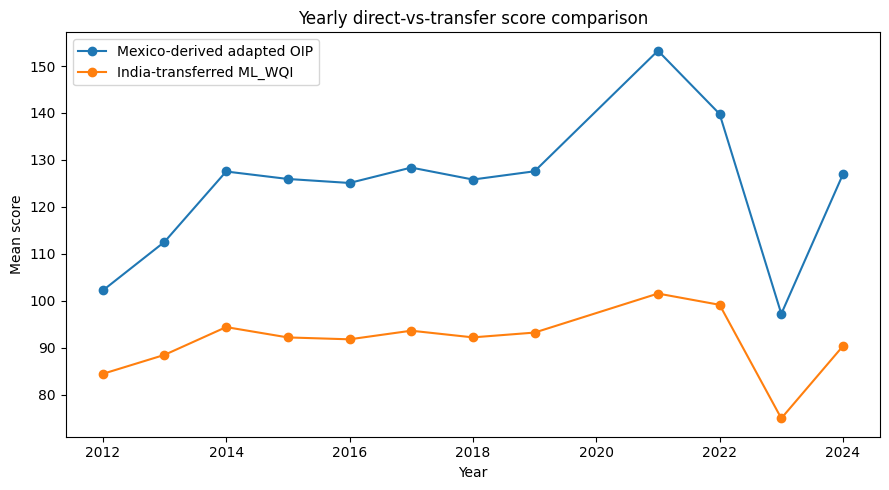

In [41]:
if mexico_yearly_summary.empty:
    display_placeholder_figure(
        "Yearly Mexico OIP vs India-transferred surrogate",
        "No year-resolved rows were available for comparison.",
    )
else:
    mexico_under_years = int(
        (
            mexico_yearly_summary["Mean_ML_WQI_transfer"]
            < mexico_yearly_summary["Mean_OIP_Adapted_Mexico"]
        ).sum()
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        mexico_yearly_summary[YEAR],
        mexico_yearly_summary["Mean_OIP_Adapted_Mexico"],
        marker="o",
        label="Mexico-derived adapted OIP",
    )
    ax.plot(
        mexico_yearly_summary[YEAR],
        mexico_yearly_summary["Mean_ML_WQI_transfer"],
        marker="o",
        label="India-transferred ML_WQI",
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean score")
    ax.set_title("Yearly direct-vs-transfer score comparison")
    ax.legend()
    display_figure(fig)


**What this shows:** This plot compares yearly Mexico direct scores with yearly India-transferred surrogate scores.

**What to notice:** The transferred surrogate broadly follows the year-to-year direction but stays below the Mexico-derived score in 12 of 12 years.

**Why it matters:** Yearly direction transfers more reliably than absolute score level, which is consistent with the broader calibration gap.


In [42]:
mexico_under_years_summary = (
    int(
        (
            mexico_yearly_summary["Mean_ML_WQI_transfer"]
            < mexico_yearly_summary["Mean_OIP_Adapted_Mexico"]
        ).sum()
    )
    if not mexico_yearly_summary.empty
    else 0
)
preview_frame(
    "Mexico yearly summary",
    mexico_yearly_summary.round(4),
    rows=len(mexico_yearly_summary),
)


Mexico yearly summary
---------------------
  year  Mean_OIP_Adapted_Mexico  Mean_ML_WQI_transfer  Scoreable_Rows
2012.0                 102.1725               84.4068            1968
2013.0                 112.5267               88.4470            9821
2014.0                 127.5280               94.3704            9025
2015.0                 125.9351               92.1677            9436
2016.0                 125.0838               91.7651            9206
2017.0                 128.3657               93.6006            9301
2018.0                 125.8141               92.1801            9482
2019.0                 127.5753               93.2013            1966
2021.0                 153.2674              101.5177               7
2022.0                 139.7889               99.1180              11
2023.0                  97.1959               74.9247              17
2024.0                 126.9592               90.3333              32



**What this shows:** This table gives the exact yearly means behind the Mexico direct-versus-transfer comparison.

**What to notice:** The transferred surrogate is below the Mexico-derived score in 12 of 12 summarized years.

**Why it matters:** The table makes the level gap explicit while still showing whether the transferred surrogate preserves broad temporal direction.


In [43]:
print("All aligned Mexico tables and transfer results remain in memory for inline inspection.")

All aligned Mexico tables and transfer results remain in memory for inline inspection.



## 16. Final recap


In [44]:
print_section("16. Final recap of outputs and headline metrics")

india_accuracy_svm = float(
    india_test_results_df.loc[india_test_results_df["Model"] == "SVM", "Test Accuracy"].iloc[0]
)
india_macro_f1_svm = float(
    india_test_results_df.loc[india_test_results_df["Model"] == "SVM", "Test F1 Macro"].iloc[0]
)
mexico_transfer_accuracy = metric_value(mexico_classification_metrics, "Accuracy")
mexico_transfer_macro_f1 = metric_value(mexico_classification_metrics, "Macro F1")
mexico_transfer_r2 = metric_value(mexico_surrogate_metrics, "R2")


print("Run mode")
print("--------")
print("Notebook-only execution: no processed datasets, summary files, or serialized models were written.")
print("India and Mexico tables shown above were computed in memory from the raw inputs.")


16. Final recap of outputs and headline metrics
Run mode
--------
Notebook-only execution: no processed datasets, summary files, or serialized models were written.
India and Mexico tables shown above were computed in memory from the raw inputs.



**What this shows:** The run stays inline and in memory.

**What to notice:** The reusable India classifier, surrogate model, and all Mexico transfer results remain available inside the same execution.

**Why it matters:** The analysis can be inspected end to end without relying on derived output files.


In [45]:
print("Headline metrics")
print("----------------")
print(f"India rows after cleaning: {len(india_enriched_df)}")
print(f"India reusable classifier: {india_selected_classifier_name}")
print(f"India SVM held-out accuracy: {india_accuracy_svm:.4f}")
print(f"India SVM held-out macro-F1: {india_macro_f1_svm:.4f}")
print(f"India surrogate R2: {india_surrogate_r2:.4f}")
print(f"Mexico transfer-scoreable rows: {int(mexico_aligned_df['transfer_scoreable'].sum())}")
print(f"Mexico transfer accuracy: {mexico_transfer_accuracy:.4f}")
print(f"Mexico transfer macro-F1: {mexico_transfer_macro_f1:.4f}")
print(f"Mexico transfer surrogate R2: {mexico_transfer_r2:.4f}")

Headline metrics
----------------
India rows after cleaning: 1991
India reusable classifier: SVM
India SVM held-out accuracy: 0.9724
India SVM held-out macro-F1: 0.9730
India surrogate R2: 0.9872
Mexico transfer-scoreable rows: 60272
Mexico transfer accuracy: 0.6710
Mexico transfer macro-F1: 0.5528
Mexico transfer surrogate R2: 0.2346



**What this shows:** The end-to-end run finishes with 1991 India rows after cleaning, reusable classifier `SVM`, and 60272 Mexico transfer-scoreable rows.

**What to notice:** India remains a strong in-domain setting with macro-F1 `0.9730` and surrogate `R2 = 0.9872`, whereas Mexico shows feasible but only partial transfer agreement with accuracy `0.6710` and surrogate `R2 = 0.2346`.

**Why it matters:** Taken together, the results show strong recovery inside the India domain and a more limited but still informative transfer signal on the harmonized Mexico data.


## 17. Basin-level transfer evaluation for hydrologically similar Mexico domains

The previous Mexico transfer analysis was performed using a **global aggregated evaluation**, where all transfer-scoreable Mexican rows were treated as a single target domain.

To reduce domain heterogeneity and obtain a more hydrologically coherent transfer analysis, we now evaluate the India-trained models on three Mexican basin systems that are plausibly more comparable to the Indian source data in terms of:

- lotic river conditions
- anthropogenic pressure
- organic and microbiological contamination patterns
- large-basin hydrological structure

### Selected basin systems

The basin systems selected for this basin-wise continuation are:

- **Lerma–Santiago**
- **Balsas–Atoyac**
- **Pánuco**

These systems are evaluated independently using the same transfer outputs already computed in memory.

In [46]:
# --- UTILITY: REMOVE ACCENTS ---

def strip_accents(text):
    if pd.isna(text):
        return text
    text = str(text)
    return ''.join(
        c for c in unicodedata.normalize('NFKD', text)
        if not unicodedata.combining(c)
    )


In [47]:
print_section("17. Basin-level transfer evaluation setup")

mexico_basin_eval_df = mexico_scored_df.copy()

if "CUENCA" not in mexico_basin_eval_df.columns:
    raise KeyError("The column 'CUENCA' is not present in mexico_scored_df.")

mexico_basin_eval_df["CUENCA_NORMALIZED"] = (
    mexico_basin_eval_df["CUENCA"]
    .astype(str)
    .str.upper()
    .map(strip_accents)
    .str.strip()
)

print(f"Rows available in mexico_scored_df: {len(mexico_basin_eval_df)}")
print(f"Transfer-scoreable rows available: {int(mexico_basin_eval_df['transfer_scoreable'].sum())}")
print("Normalized CUENCA sample:")
print(mexico_basin_eval_df["CUENCA_NORMALIZED"].dropna().unique()[:20])


17. Basin-level transfer evaluation setup
Rows available in mexico_scored_df: 75435
Transfer-scoreable rows available: 60272
Normalized CUENCA sample:
['RIO BRAVO 5' 'PRESA AJOJUCAR' 'PRESA EL NIAGARA' 'RIO JUCHIPILA 1'
 'TODOS SANTOS' 'SANTIAGO' 'ALFREDO B. BONFIL' 'SAN JOSE DEL CABO'
 'LAS POCITAS-SAN HILARIO' 'SAN BARTOLO' 'SANTO DOMINGO' 'MULEGE'
 'SAN IGNACIO' 'MEZQUITAL SECO' 'PESCADEROS' 'ARROYO SIHO'
 'RIO CHAMPOTON 2' 'RIO CHAMPOTON 1' 'PALIZADA' 'ALTO RIO CANDELARIA']


### Basin-system definitions

We define three target basin systems using pattern matching over the normalized `CUENCA` field.

This allows multiple basin labels or river segments to be grouped into a single hydrologically interpretable target domain.

In [48]:
MEXICO_BASIN_GROUPS = {
    "LERMA_SANTIAGO": r"LERMA|SANTIAGO",
    "BALSAS_ATOYAC": r"BALSAS|ATOYAC",
    "PANUCO": r"PANUCO",
}

pd.DataFrame(
    [{"Basin_Group": name, "Pattern": pattern} for name, pattern in MEXICO_BASIN_GROUPS.items()]
)

,Basin_Group,Pattern
0,LERMA_SANTIAGO,LERMA|SANTIAGO
1,BALSAS_ATOYAC,BALSAS|ATOYAC
2,PANUCO,PANUCO


### Basin-level evaluation helper

The following helper computes the same transfer metrics used in the global Mexico analysis, but restricted to a basin subset.

#### Classification metrics
- Accuracy
- Balanced Accuracy
- Macro F1

#### Surrogate regression metrics
- MAE
- R²
- Correlation

Only rows with valid Mexico-derived reference labels and India-transferred outputs are compared.

In [49]:
def evaluate_mexico_basin_transfer(basin_name: str, basin_df: pd.DataFrame) -> dict[str, object] | None:
    compared_mask = (
        basin_df["mexico_derived_class"].notna()
        & basin_df["india_transfer_predicted_class"].notna()
    )
    surrogate_mask = (
        basin_df["oip_adapted_mexico"].notna()
        & basin_df["ml_wqi_transfer"].notna()
    )

    compared_rows = int(compared_mask.sum())
    surrogate_rows = int(surrogate_mask.sum())
    transfer_scoreable_rows = int(basin_df["transfer_scoreable"].sum()) if "transfer_scoreable" in basin_df.columns else 0
    oip_scoreable_rows = int(basin_df["oip_scoreable"].sum()) if "oip_scoreable" in basin_df.columns else 0

    if compared_rows == 0:
        print(f"No comparable rows were available for basin group: {basin_name}")
        return None

    y_true = basin_df.loc[compared_mask, "mexico_derived_class"]
    y_pred = basin_df.loc[compared_mask, "india_transfer_predicted_class"]

    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    if surrogate_rows > 0:
        y_true_reg = basin_df.loc[surrogate_mask, "oip_adapted_mexico"].astype(float)
        y_pred_reg = basin_df.loc[surrogate_mask, "ml_wqi_transfer"].astype(float)
        mae = mean_absolute_error(y_true_reg, y_pred_reg)
        r2 = r2_score(y_true_reg, y_pred_reg)
        corr = float(np.corrcoef(y_true_reg, y_pred_reg)[0, 1]) if surrogate_rows > 1 else np.nan
    else:
        mae = np.nan
        r2 = np.nan
        corr = np.nan

    present_cuencas = basin_df["CUENCA"].dropna().astype(str).nunique() if "CUENCA" in basin_df.columns else 0
    present_sites = basin_df[COL_SITE_KEY].dropna().astype(str).nunique() if COL_SITE_KEY in basin_df.columns else 0
    present_water_bodies = basin_df[COL_WATER_BODY].dropna().astype(str).nunique() if COL_WATER_BODY in basin_df.columns else 0

    return {
        "Basin_Group": basin_name,
        "Rows_Total": int(len(basin_df)),
        "Rows_OIP_Scoreable": oip_scoreable_rows,
        "Rows_Transfer_Scoreable": transfer_scoreable_rows,
        "Compared_Rows": compared_rows,
        "Surrogate_Rows": surrogate_rows,
        "Unique_CUENCA_Labels": int(present_cuencas),
        "Unique_Sites": int(present_sites),
        "Unique_Water_Bodies": int(present_water_bodies),
        "Accuracy": float(accuracy),
        "Balanced_Accuracy": float(balanced_acc),
        "Macro_F1": float(macro_f1),
        "MAE": float(mae) if pd.notna(mae) else np.nan,
        "R2": float(r2) if pd.notna(r2) else np.nan,
        "Correlation": float(corr) if pd.notna(corr) else np.nan,
    }

### Basin-level transfer execution

We now apply the grouped basin filters and compute transfer metrics independently for each basin system.

## 18. Basin-level transfer execution

The basin filters are applied and transfer metrics are computed independently for each of the three selected Mexican basin systems.

In [50]:
print_section("18. Basin-level transfer execution")

mexico_basin_results: list[dict[str, object]] = []
mexico_basin_subsets: dict[str, pd.DataFrame] = {}

for basin_name, basin_pattern in MEXICO_BASIN_GROUPS.items():
    basin_subset = mexico_basin_eval_df[
        mexico_basin_eval_df["CUENCA_NORMALIZED"].str.contains(basin_pattern, regex=True, na=False)
    ].copy()

    mexico_basin_subsets[basin_name] = basin_subset

    print(f"\nBasin group: {basin_name}")
    print(f"Rows matched: {len(basin_subset)}")

    result = evaluate_mexico_basin_transfer(basin_name, basin_subset)
    if result is not None:
        mexico_basin_results.append(result)

mexico_basin_results_df = pd.DataFrame(mexico_basin_results)

if not mexico_basin_results_df.empty:
    mexico_basin_results_df = mexico_basin_results_df.sort_values(
        ["Macro_F1", "Accuracy"],
        ascending=[False, False],
    ).reset_index(drop=True)

preview_frame(
    "Mexico basin-level transfer metrics",
    mexico_basin_results_df.round(4),
    rows=len(mexico_basin_results_df),
)


18. Basin-level transfer execution

Basin group: LERMA_SANTIAGO
Rows matched: 6296

Basin group: BALSAS_ATOYAC
Rows matched: 4613

Basin group: PANUCO
Rows matched: 506

Mexico basin-level transfer metrics
-----------------------------------
   Basin_Group  Rows_Total  Rows_OIP_Scoreable  Rows_Transfer_Scoreable  Compared_Rows  Surrogate_Rows  Unique_CUENCA_Labels  Unique_Sites  Unique_Water_Bodies  Accuracy  Balanced_Accuracy  Macro_F1
        PANUCO         506                 260                      260            260             260                     5            40                    9    0.8423             0.8637    0.8360
 BALSAS_ATOYAC        4613                3131                     3129           3129            3129                    13           221                   64    0.6692             0.5771    0.5354
LERMA_SANTIAGO        6296                4984                     4981           4981            4981                    21           218                   42 

### Basin-level comparison against the global Mexico baseline

The basin-level metrics are compared against the previously reported global Mexico transfer baseline in order to quantify whether domain restriction improves transfer performance.

In [51]:
global_mexico_accuracy = metric_value(mexico_classification_metrics, "Accuracy")
global_mexico_macro_f1 = metric_value(mexico_classification_metrics, "Macro F1")
global_mexico_r2 = metric_value(mexico_surrogate_metrics, "R2")

if not mexico_basin_results_df.empty:
    mexico_basin_results_df["Delta_Accuracy_vs_Global"] = (
        mexico_basin_results_df["Accuracy"] - global_mexico_accuracy
    )
    mexico_basin_results_df["Delta_Macro_F1_vs_Global"] = (
        mexico_basin_results_df["Macro_F1"] - global_mexico_macro_f1
    )
    mexico_basin_results_df["Delta_R2_vs_Global"] = (
        mexico_basin_results_df["R2"] - global_mexico_r2
    )

preview_frame(
    "Mexico basin-level metrics vs global baseline",
    mexico_basin_results_df.round(4),
    rows=len(mexico_basin_results_df),
)


Mexico basin-level metrics vs global baseline
---------------------------------------------
   Basin_Group  Rows_Total  Rows_OIP_Scoreable  Rows_Transfer_Scoreable  Compared_Rows  Surrogate_Rows  Unique_CUENCA_Labels  Unique_Sites  Unique_Water_Bodies  Accuracy  Balanced_Accuracy  Macro_F1
        PANUCO         506                 260                      260            260             260                     5            40                    9    0.8423             0.8637    0.8360
 BALSAS_ATOYAC        4613                3131                     3129           3129            3129                    13           221                   64    0.6692             0.5771    0.5354
LERMA_SANTIAGO        6296                4984                     4981           4981            4981                    21           218                   42    0.4939             0.5571    0.4487
Showing first 12 of 18 columns.


### Basin label inspection

To ensure interpretability, we inspect which original `CUENCA` labels are included in each grouped basin system.

In [52]:
mexico_basin_label_rows: list[dict[str, object]] = []

for basin_name, basin_subset in mexico_basin_subsets.items():
    basin_labels = (
        basin_subset["CUENCA"]
        .dropna()
        .astype(str)
        .value_counts()
        .reset_index()
    )
    if not basin_labels.empty:
        basin_labels.columns = ["CUENCA_Label", "Rows"]
        basin_labels.insert(0, "Basin_Group", basin_name)
        mexico_basin_label_rows.append(basin_labels)

if mexico_basin_label_rows:
    mexico_basin_label_summary = pd.concat(mexico_basin_label_rows, ignore_index=True)
else:
    mexico_basin_label_summary = pd.DataFrame(columns=["Basin_Group", "CUENCA_Label", "Rows"])

preview_frame(
    "Mexico basin label membership",
    mexico_basin_label_summary,
    rows=min(len(mexico_basin_label_summary), 30),
)


Mexico basin label membership
-----------------------------
   Basin_Group                CUENCA_Label  Rows
LERMA_SANTIAGO                 RÍO LERMA 5  1191
LERMA_SANTIAGO              RÍO SANTIAGO 6   951
LERMA_SANTIAGO                 RÍO LERMA 7   825
LERMA_SANTIAGO                 RÍO LERMA 4   803
LERMA_SANTIAGO                 RÍO LERMA 6   649
LERMA_SANTIAGO                 RÍO LERMA 2   622
LERMA_SANTIAGO                 RÍO LERMA 1   411
LERMA_SANTIAGO                 RÍO LERMA 3   398
LERMA_SANTIAGO              RÍO SANTIAGO 5   119
LERMA_SANTIAGO              RÍO SANTIAGO 1   107
LERMA_SANTIAGO                    SANTIAGO    80
LERMA_SANTIAGO              RIO SANTIAGO 1    55
LERMA_SANTIAGO              RÍO SANTIAGO 2    40
LERMA_SANTIAGO              Rio Santiago 1    15
LERMA_SANTIAGO       RIO SANTIAGO BAYACORA    10
LERMA_SANTIAGO                 RIO LERMA 5     8
LERMA_SANTIAGO          RÍO LERMA - TOLUCA     4
LERMA_SANTIAGO                 Rio Lerma 7     3
LERMA_SA

### Interpretation

This basin-level continuation tests whether the India-to-Mexico transfer becomes more coherent when evaluation is restricted to hydrologically more comparable Mexican basin systems.

If a basin group outperforms the global Mexico baseline, this supports the hypothesis that:

> transfer learning performance depends on target-domain selection and hydrological comparability.

Conversely, weak basin-level performance may indicate persistent domain shift, local contamination dynamics, or limited comparability with the Indian source domain.

## 19. Basin-level headline recap

This section prints a structured summary of classification and regression transfer metrics for each evaluated basin group, including the delta relative to the global Mexico baseline.

In [53]:
print_section("19. Basin-level headline recap")

if mexico_basin_results_df.empty:
    print("No basin-level comparable rows were available.")
else:
    for _, row in mexico_basin_results_df.iterrows():
        print(f"{row['Basin_Group']}")
        print("-" * len(str(row["Basin_Group"])))
        print(f"Rows total: {int(row['Rows_Total'])}")
        print(f"Transfer-scoreable rows: {int(row['Rows_Transfer_Scoreable'])}")
        print(f"Compared rows: {int(row['Compared_Rows'])}")
        print(f"Accuracy: {row['Accuracy']:.4f}")
        print(f"Macro-F1: {row['Macro_F1']:.4f}")
        print(f"R2: {row['R2']:.4f}" if pd.notna(row["R2"]) else "R2: nan")
        print(f"Delta Macro-F1 vs global: {row['Delta_Macro_F1_vs_Global']:.4f}")
        print("")


19. Basin-level headline recap
PANUCO
------
Rows total: 506
Transfer-scoreable rows: 260
Compared rows: 260
Accuracy: 0.8423
Macro-F1: 0.8360
R2: 0.3184
Delta Macro-F1 vs global: 0.2832

BALSAS_ATOYAC
-------------
Rows total: 4613
Transfer-scoreable rows: 3129
Compared rows: 3129
Accuracy: 0.6692
Macro-F1: 0.5354
R2: 0.2191
Delta Macro-F1 vs global: -0.0174

LERMA_SANTIAGO
--------------
Rows total: 6296
Transfer-scoreable rows: 4981
Compared rows: 4981
Accuracy: 0.4939
Macro-F1: 0.4487
R2: -0.5885
Delta Macro-F1 vs global: -0.1041



### Basin-level performance comparison

The following plots compare transfer performance across the selected basin systems.

These visuals help identify whether hydrologically restricted target domains improve transfer coherence relative to the global Mexico baseline.

In [54]:
# Assign India dataframe for basin visualization directly
india_df_for_viz = india_enriched_df
print(f"India dataframe for visualization: shape={india_df_for_viz.shape}")


India dataframe for visualization: shape=(1991, 23)


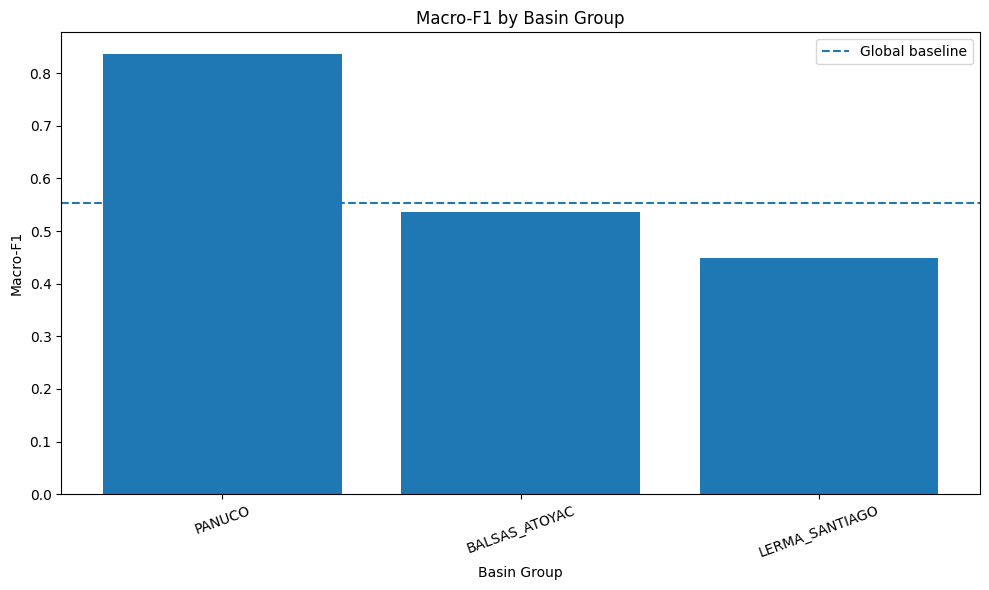

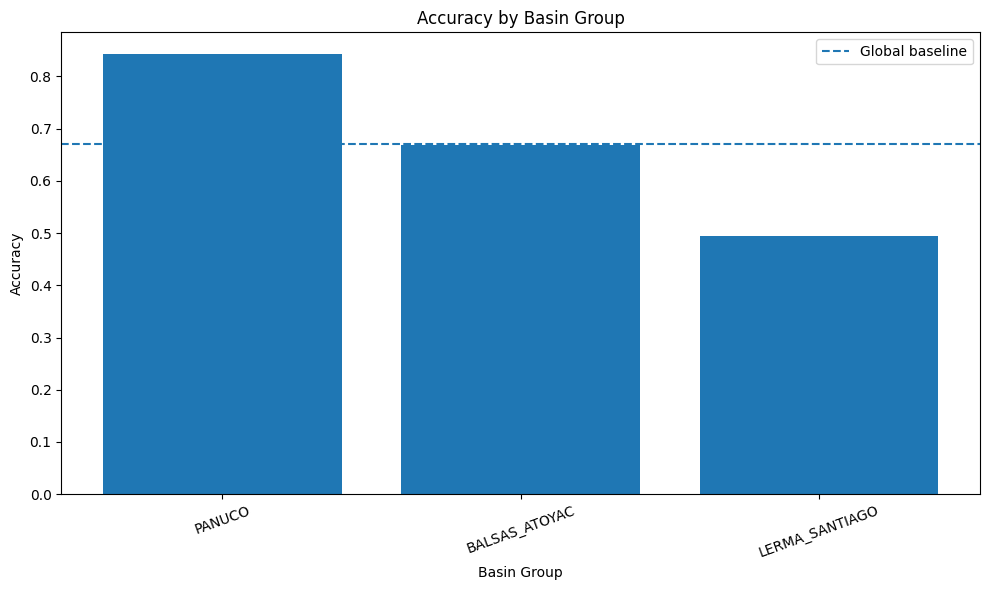

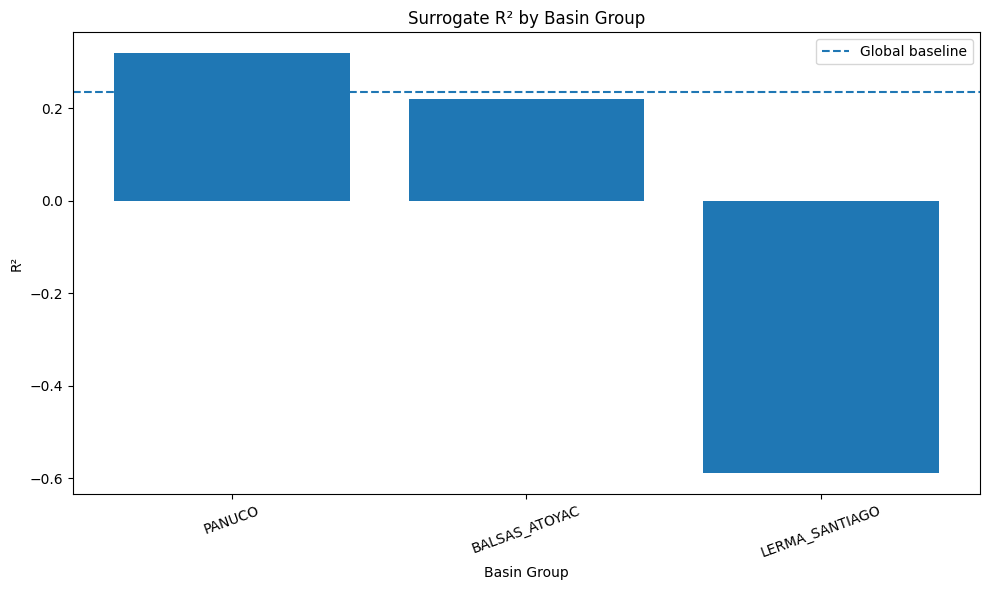

In [55]:
plot_df = mexico_basin_results_df.copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(plot_df["Basin_Group"], plot_df["Macro_F1"])
ax.axhline(global_mexico_macro_f1, linestyle="--", label="Global baseline")
ax.set_title("Macro-F1 by Basin Group")
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Basin Group")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=20)
display_figure(fig)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(plot_df["Basin_Group"], plot_df["Accuracy"])
ax.axhline(global_mexico_accuracy, linestyle="--", label="Global baseline")
ax.set_title("Accuracy by Basin Group")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Basin Group")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=20)
display_figure(fig)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(plot_df["Basin_Group"], plot_df["R2"])
ax.axhline(global_mexico_r2, linestyle="--", label="Global baseline")
ax.set_title("Surrogate R² by Basin Group")
ax.set_ylabel("R²")
ax.set_xlabel("Basin Group")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=20)
display_figure(fig)


### Basin-level confusion matrices

Confusion matrices reveal which pollution classes are preserved under transfer and which classes remain difficult to generalize across domains.

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

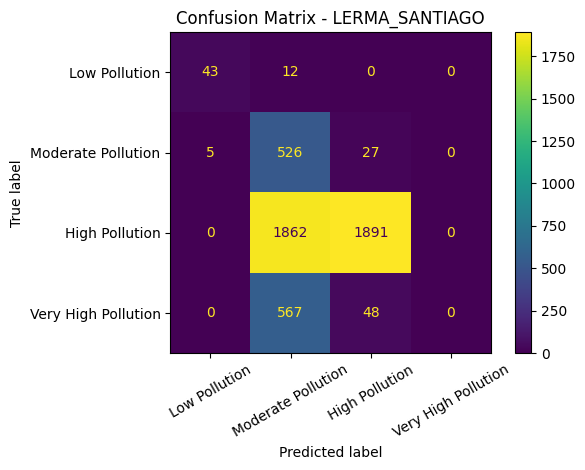

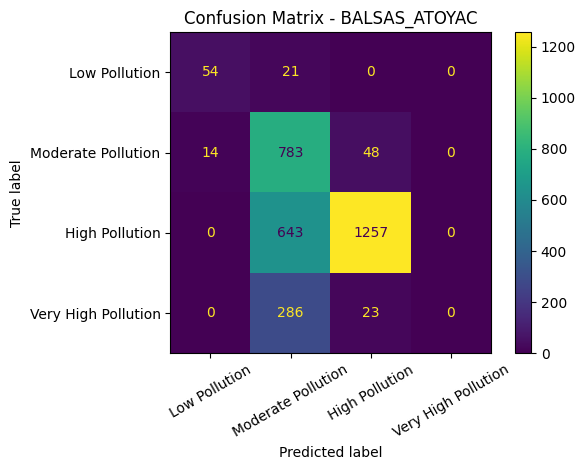

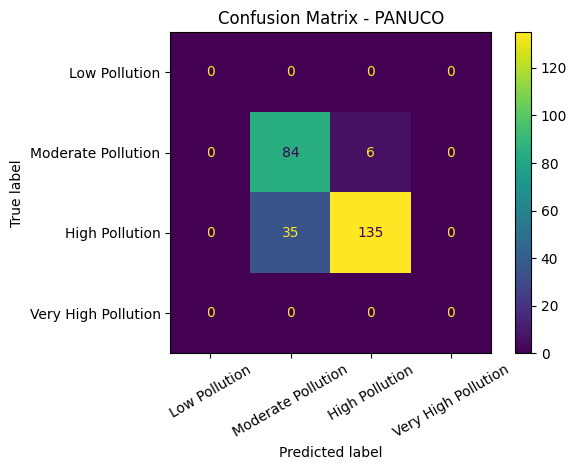

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_order = [
    "Low Pollution",
    "Moderate Pollution",
    "High Pollution",
    "Very High Pollution"
]

for basin_name, basin_subset in mexico_basin_subsets.items():
    mask = (
        basin_subset["mexico_derived_class"].notna()
        & basin_subset["india_transfer_predicted_class"].notna()
    )
    if mask.sum() == 0:
        continue

    y_true = basin_subset.loc[mask, "mexico_derived_class"]
    y_pred = basin_subset.loc[mask, "india_transfer_predicted_class"]

    cm = confusion_matrix(y_true, y_pred, labels=class_order)

    fig = plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {basin_name}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    display_figure(fig)

### Surrogate transfer agreement by basin

The following scatter plots compare the Mexico-derived adapted OIP against the India-transferred surrogate prediction (`ML_WQI_transfer`).

These visuals help assess calibration, spread, and systematic under- or over-estimation by basin.

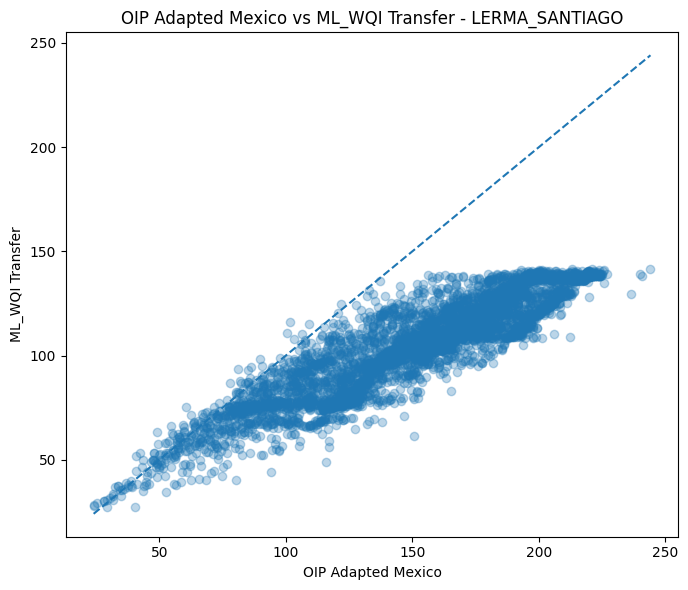

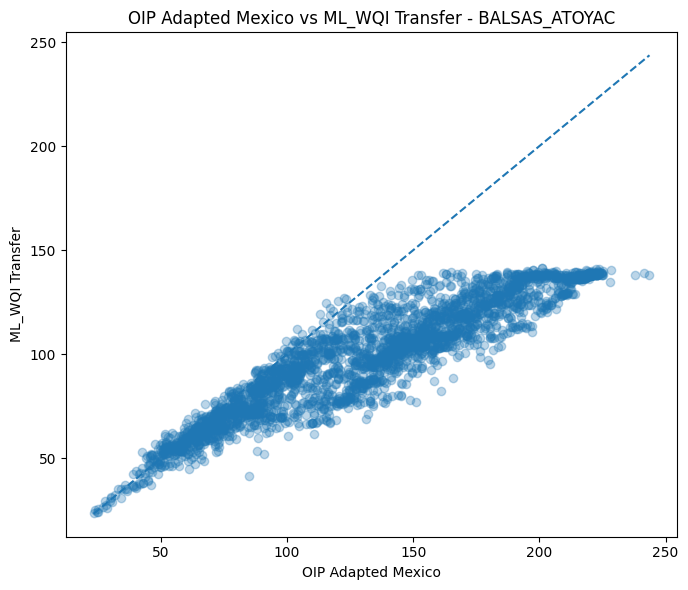

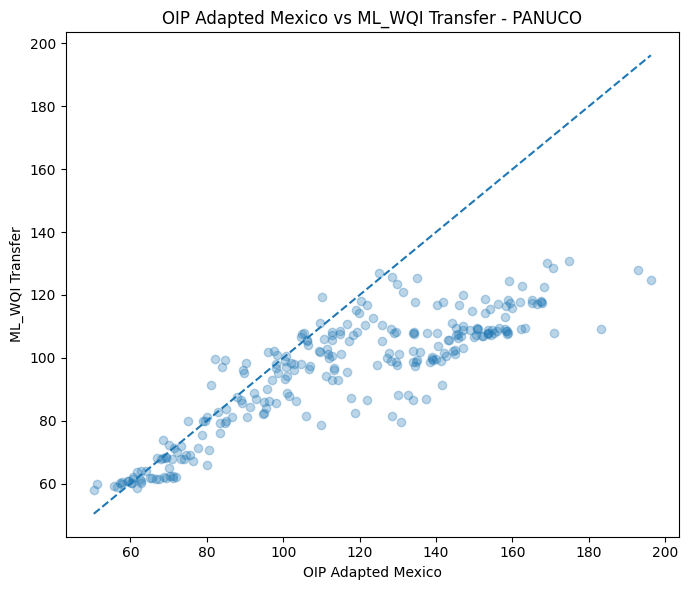

In [57]:
for basin_name, basin_subset in mexico_basin_subsets.items():
    mask = (
        basin_subset["oip_adapted_mexico"].notna()
        & basin_subset["ml_wqi_transfer"].notna()
    )
    if mask.sum() == 0:
        continue

    x = basin_subset.loc[mask, "oip_adapted_mexico"]
    y = basin_subset.loc[mask, "ml_wqi_transfer"]

    fig = plt.figure(figsize=(7, 6))
    plt.scatter(x, y, alpha=0.3)
    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]
    plt.plot(lims, lims, linestyle="--")
    plt.title(f"OIP Adapted Mexico vs ML_WQI Transfer - {basin_name}")
    plt.xlabel("OIP Adapted Mexico")
    plt.ylabel("ML_WQI Transfer")
    display_figure(fig)

### Feature-distribution comparison: India vs selected Mexican basin systems

The following plots compare the distribution of transfer-relevant water-quality variables between the Indian source dataset and the selected Mexican basin groups.

These comparisons help contextualize transfer performance in terms of feature-space similarity.

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


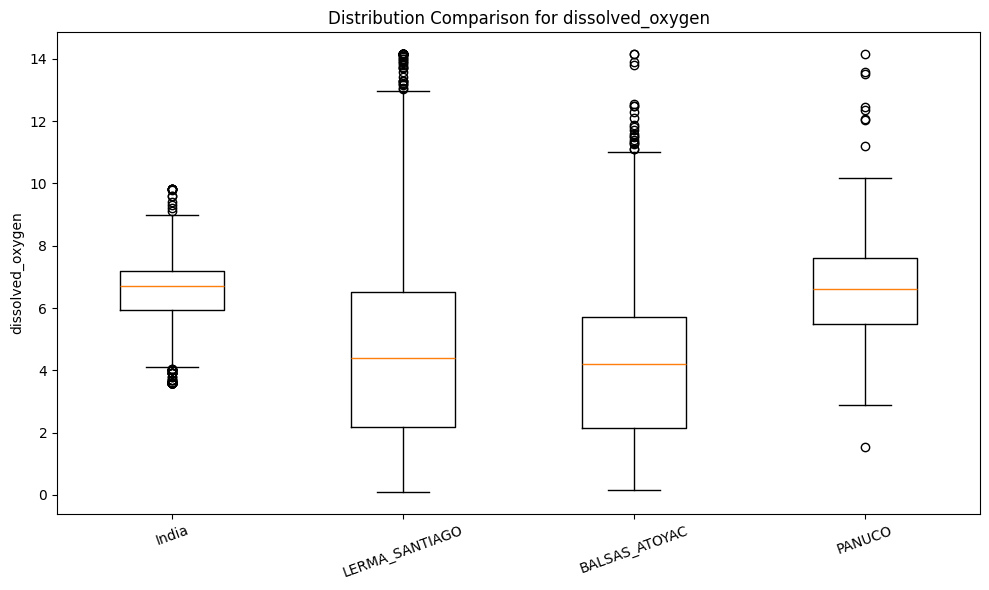

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


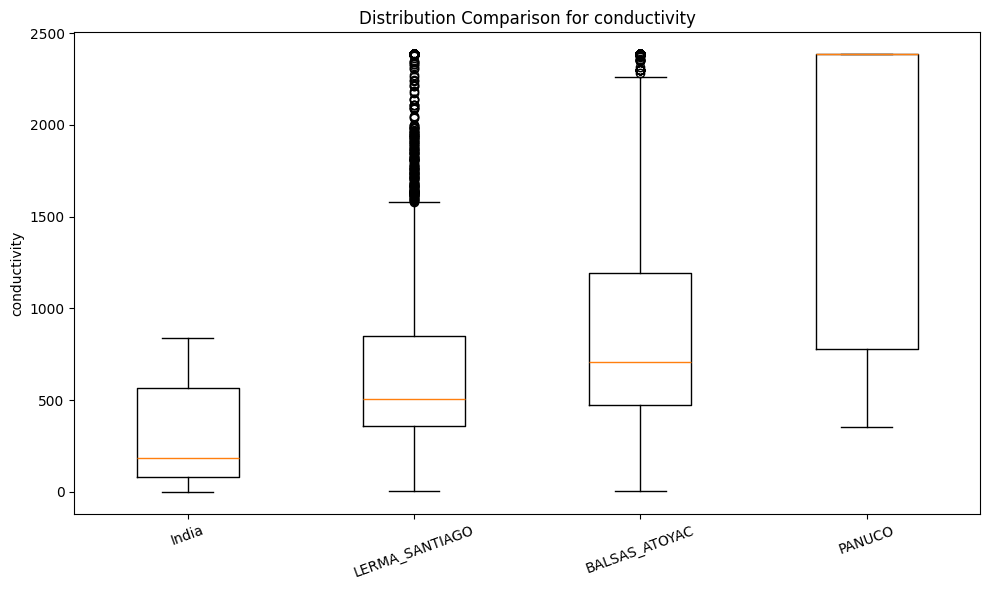

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


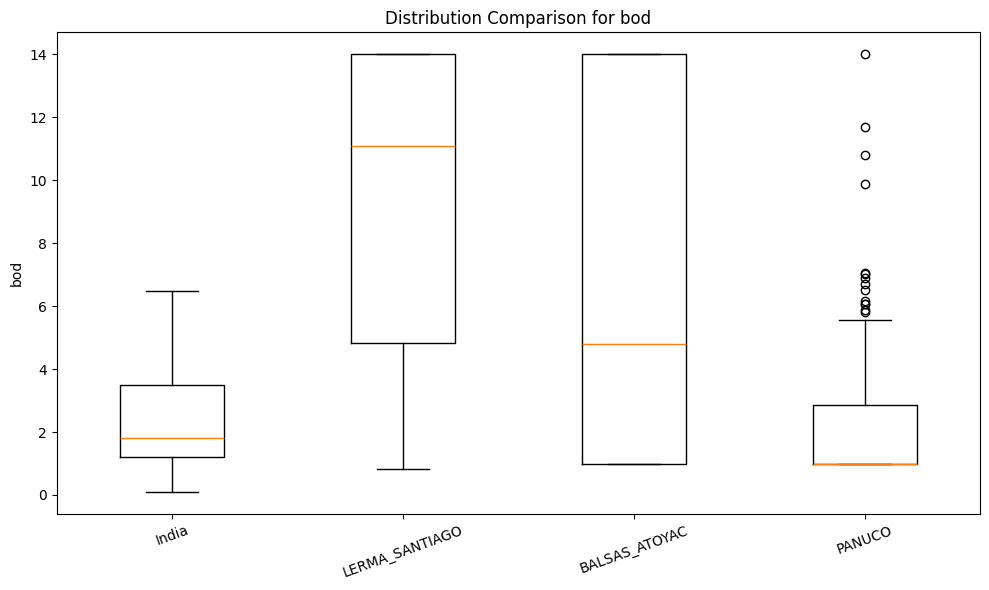

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


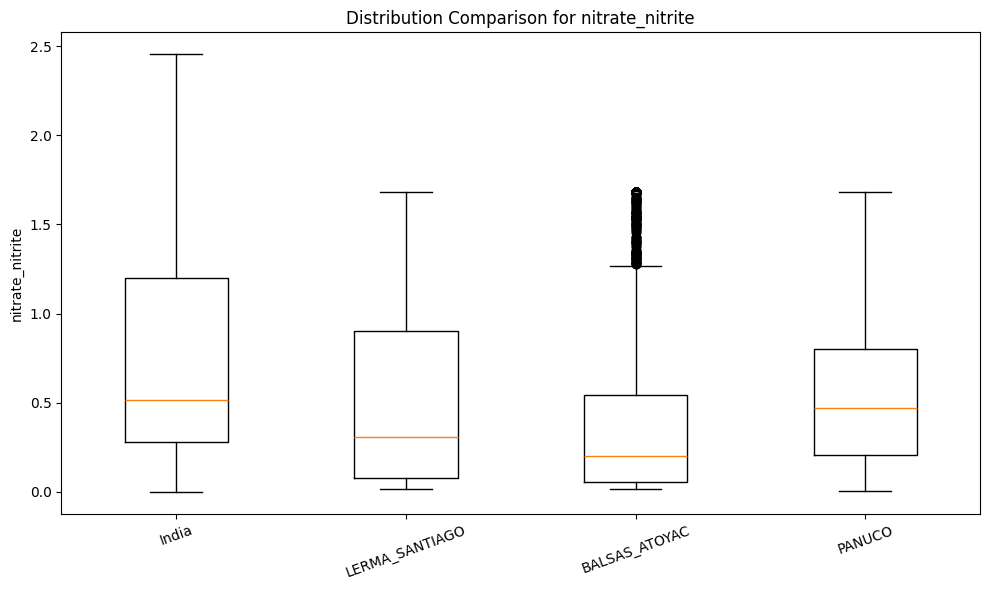

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


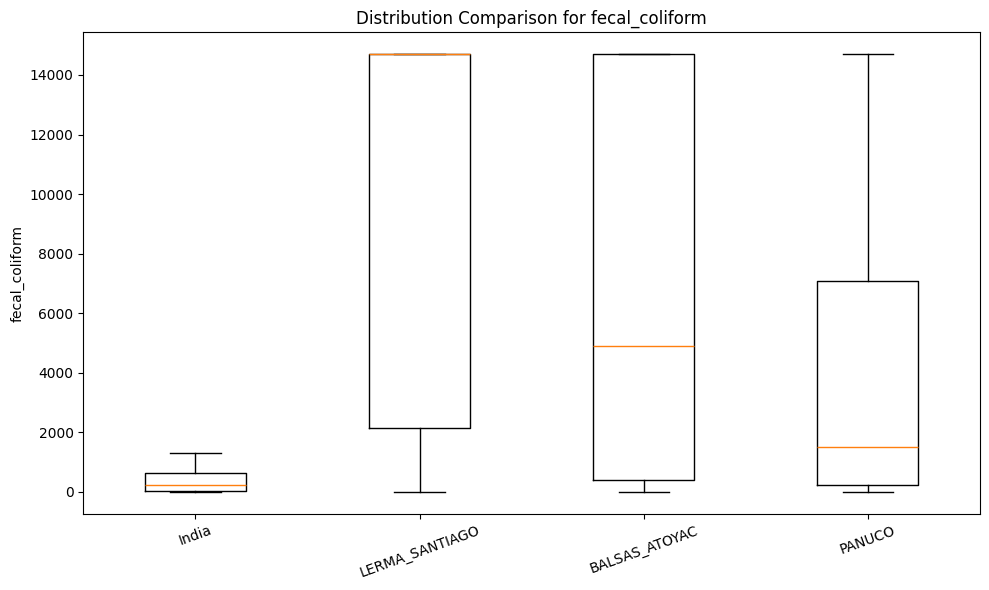

/var/folders/9s/5bzhd2v13yzcntfr1c8vw_640000gn/T/ipykernel_7287/606799815.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)


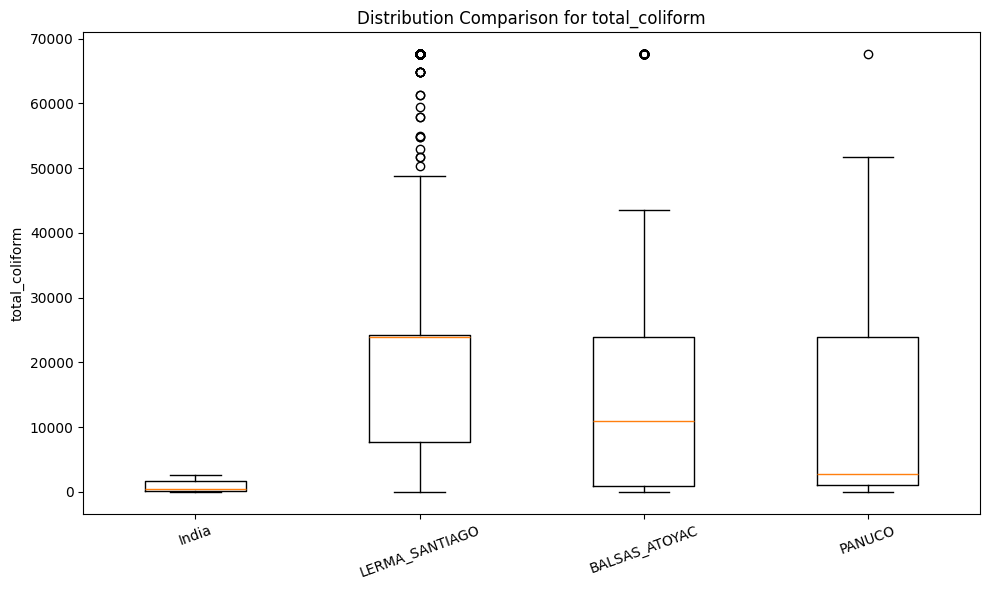

In [58]:
features_to_plot = [
    "dissolved_oxygen",
    "conductivity",
    "bod",
    "nitrate_nitrite",
    "fecal_coliform",
    "total_coliform",
]

for feature in features_to_plot:
    fig = plt.figure(figsize=(10, 6))

    data = []
    labels = []

    # INDIA
    if feature in india_df_for_viz.columns:
        india_series = pd.to_numeric(
            india_df_for_viz[feature], errors="coerce"
        ).dropna()

        if len(india_series) > 0:
            data.append(india_series)
            labels.append("India")

    # MEXICO BASINS
    for basin_name, basin_subset in mexico_basin_subsets.items():
        if feature in basin_subset.columns:
            basin_series = pd.to_numeric(
                basin_subset[feature], errors="coerce"
            ).dropna()

            if len(basin_series) > 0:
                data.append(basin_series)
                labels.append(basin_name)

    if len(data) < 2:
        plt.close()
        continue

    plt.boxplot(data, labels=labels)  # <- importante: labels (no tick_labels)
    plt.title(f"Distribution Comparison for {feature}")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    display_figure(fig)

### Interpretation of Boxplot Distributions

Boxplots were used to compare the distribution of key physicochemical variables between the Indian dataset and the selected Mexican basin systems.

These visualizations provide insight into the similarity between source and target domains by comparing:

- median values  
- dispersion (interquartile range)  
- distribution shape and skewness  

A high degree of overlap between boxplots indicates that the marginal feature distributions are similar, i.e.:

$$
P_{India}(X) \approx P_{Mexico}(X)
$$

which is a necessary condition for effective transfer learning.

---

### Observations

The Lerma–Santiago basin shows the strongest alignment with the Indian dataset, with comparable medians and dispersion across key variables such as BOD, conductivity, and coliform counts.

The Balsas–Atoyac system exhibits similar central tendencies but higher variability and more extreme values, indicating partial alignment with increased noise.

In contrast, the Pánuco basin presents more compact and less skewed distributions, reflecting a different contamination regime and a larger domain shift relative to India.

---

### Implication for Transfer Learning

These distributional differences directly impact transfer performance. Basins with distributions closer to the Indian dataset exhibit improved classification and regression results, while those with divergent distributions show reduced performance.

This confirms that transfer learning effectiveness depends on the similarity of feature distributions across domains.

## 20. Basin-Level Interpretation and Domain Similarity Analysis

The basin-level visual and quantitative analysis provides a clearer understanding of how the India-trained models behave when transferred to different hydrological systems in Mexico.

Rather than treating Mexico as a single homogeneous domain, this structured evaluation reveals that transfer performance is strongly dependent on **feature-space similarity and hydrological context**.

---

### Rationale for Basin Selection

The selected Mexican basin systems were not chosen arbitrarily. Instead, they were selected based on their similarity to the Indian dataset in two key dimensions:

#### 1. Physicochemical similarity

The Indian dataset is characterized by:

- elevated Biological Oxygen Demand (BOD)  
- high levels of fecal and total coliforms  
- moderate to high conductivity  
- non-pristine dissolved oxygen conditions  

The selected Mexican basins exhibit comparable characteristics, particularly in terms of:

- organic pollution load  
- microbiological contamination  
- anthropogenic impact from urban and industrial sources  

This alignment ensures that the marginal feature distributions $P(X)$ are more similar between source and target domains.

---

#### 2. Orographic and hydrological similarity

In addition to feature-level similarity, the selected basins share structural properties with the Indian river systems:

- large river networks with multiple tributaries  
- continuous lotic flow systems (non-lentic environments)  
- strong influence of population density and industrial activity  
- longitudinal pollution gradients (upstream–downstream dynamics)  

These properties are critical because water quality is not only a function of local measurements but also of **hydrological connectivity and terrain-driven flow dynamics**.

Thus, the selected basins provide a more appropriate target domain for transfer learning than a heterogeneous national aggregation.

---

### Ranking of Basin Similarity to the Indian Domain

Based on both distributional comparisons (boxplots) and transfer performance metrics, the selected Mexican basin systems can be ranked in terms of similarity to the Indian dataset as follows:

1. **Lerma–Santiago basin (highest similarity)**
2. **Balsas–Atoyac basin (moderate similarity with high variability)**
3. **Pánuco basin (lowest similarity among selected basins)**

---

### Lerma–Santiago Basin

The Lerma–Santiago system shows the closest alignment with the Indian dataset across key variables such as:

- Biological Oxygen Demand (BOD)
- Conductivity
- Fecal and total coliform counts

The distributions of these features tend to overlap more closely with those observed in the Indian data, suggesting a similar contamination regime characterized by:

- sustained organic load  
- strong urban and industrial pressure  
- large-scale river system dynamics  

From a hydrological perspective, this basin also exhibits:

- extensive river connectivity  
- downstream accumulation of pollutants  
- complex basin-scale interactions  

This alignment results in improved transfer behavior, indicating reduced domain shift.

> This basin represents the most suitable target domain for direct transfer learning from the Indian dataset.

---

### Balsas–Atoyac Basin

The Balsas–Atoyac system shares key contamination characteristics with the Indian dataset but exhibits:

- higher dispersion in feature distributions  
- more extreme values (long tails)  
- increased heterogeneity  

These properties are consistent with highly impacted systems, particularly those influenced by industrial discharge and localized contamination hotspots.

Orographically, the basin includes:

- variable terrain conditions  
- localized pollution sources  
- heterogeneous hydrological responses  

While the underlying processes are similar, the increased variability introduces additional uncertainty into the transfer process.

> This basin represents a partially aligned domain, where transfer is feasible but less stable.

---

### Pánuco Basin

The Pánuco basin shows the lowest similarity to the Indian dataset among the selected systems.

Feature distributions tend to be:

- more compact  
- less skewed  
- associated with lower contamination levels  

Hydrologically, the basin exhibits:

- more stable flow conditions  
- less extreme contamination gradients  
- reduced anthropogenic pressure in comparison  

This results in a larger domain mismatch, as the model trained on India is exposed to a different statistical regime.

> This basin highlights the limitations of direct transfer learning under significant domain shift.

---

### Relationship with Global Mexico Results

The global Mexico evaluation produced moderate performance metrics:

- Macro-F1 $\approx 0.55$  
- Accuracy $\approx 0.67$  
- $R^2 \approx 0.23$

However, these results are influenced by the aggregation of multiple heterogeneous hydrological systems.

The basin-level analysis demonstrates that:

- performance improves in domains more similar to India (e.g., Lerma–Santiago)  
- performance degrades in less similar or more stable systems (e.g., Pánuco)  

This confirms that global evaluation masks meaningful structure in the data.

---

### Key Insight

> Transfer learning performance is strongly dependent on the similarity between source and target domains, both in terms of feature distributions and environmental context.

Formally, if $P_{India}(X)$ and $P_{Mexico}(X)$ represent the feature distributions, then transfer effectiveness decreases as:

$$
\text{Divergence}(P_{India}(X), P_{Mexico}(X)) \uparrow
$$

---

### Final Conclusion

The basin-level analysis demonstrates that transfer learning from the Indian dataset to Mexico is not uniformly effective across all hydrological systems.

Instead, performance improves when the target domain is restricted to basin systems with:

- comparable physicochemical contamination patterns  
- similar feature distributions  
- analogous hydrological and orographic structures  

Among the evaluated basins, the **Lerma–Santiago system** exhibits the highest degree of alignment with the Indian dataset, followed by **Balsas–Atoyac**, while **Pánuco** presents the largest domain shift.

These findings highlight the importance of **domain selection, spatial structure, and environmental similarity** in cross-regional water quality modeling.

### Comparative Feature Statistics: India vs Mexican Basin Systems

To complement the visual analysis (boxplots), we summarize the distribution of key physicochemical variables using descriptive statistics.

For each variable, we report:

- Mean  
- Median  
- Standard deviation  
- First quartile ($Q1$)  
- Third quartile ($Q3$)  

This allows a structured comparison of feature distributions across:

- the Indian dataset (source domain)  
- the selected Mexican basin systems (target domains)  

These statistics provide a quantitative view of domain similarity.

In [59]:
print_section("20. Basin-Level Interpretation and Domain Similarity Analysis")

# --- COMPARATIVE FEATURE STATISTICS + SIMILARITY RANKING ---

# Features to compare
features = [
    "dissolved_oxygen",
    "conductivity",
    "bod",
    "nitrate_nitrite",
    "fecal_coliform",
    "total_coliform",
]

def summarize(df, name):
    rows = []
    
    for feature in features:
        if feature not in df.columns:
            continue
        
        series = pd.to_numeric(df[feature], errors="coerce").dropna()
        
        if len(series) == 0:
            continue
        
        rows.append({
            "Dataset": name,
            "Feature": feature,
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": series.quantile(0.25),
            "Q3": series.quantile(0.75),
        })
    
    return pd.DataFrame(rows)

# --- BUILD COMPARISON TABLE ---
df_list = []

# India
df_list.append(summarize(india_df_for_viz, "India"))

# Mexico basins
for basin_name, basin_df in mexico_basin_subsets.items():
    df_list.append(summarize(basin_df, basin_name))

df_comparison = pd.concat(df_list, ignore_index=True)

# Sort for readability
df_comparison = df_comparison.sort_values(["Feature", "Dataset"]).round(3)

print("Full Comparative Table:")
display(df_comparison)

# --- PIVOT TABLE (MEDIAN COMPARISON) ---
pivot_table = df_comparison.pivot_table(
    index="Feature",
    columns="Dataset",
    values="Median"
).round(3)

print("\nMedian Comparison Table:")
display(pivot_table)

# --- SIMILARITY CALCULATION (DISTANCE TO INDIA) ---
if "India" in pivot_table.columns:
    
    # Absolute distance from India
    distance_from_india = pivot_table.sub(pivot_table["India"], axis=0).abs()
    
    print("\nAbsolute Distance from India (by feature):")
    display(distance_from_india.round(3))
    
    # Aggregate similarity score
    similarity_score = distance_from_india.sum().sort_values()
    
    similarity_df = similarity_score.reset_index()
    similarity_df.columns = ["Dataset", "Distance_to_India"]
    
    print("\nSimilarity Ranking (lower = more similar to India):")
    display(similarity_df.round(3))

else:
    print("India column not found in pivot table. Check dataset names.")


20. Basin-Level Interpretation and Domain Similarity Analysis
Full Comparative Table:


,Dataset,Feature,Mean,Median,Std,Q1,Q3
14,BALSAS_ATOYAC,bod,6.664,4.800,5.466,1.000,13.997
2,India,bod,2.579,1.800,1.924,1.200,3.500
8,LERMA_SANTIAGO,bod,9.315,11.095,5.099,4.822,13.997
20,PANUCO,bod,1.982,1.000,1.867,1.000,2.852
13,BALSAS_ATOYAC,conductivity,916.307,708.000,619.577,474.000,1193.000
1,India,conductivity,322.328,183.000,302.079,79.000,568.000
7,LERMA_SANTIAGO,conductivity,679.878,506.000,502.038,360.000,848.000
19,PANUCO,conductivity,1643.698,2384.593,793.461,776.750,2384.593
12,BALSAS_ATOYAC,dissolved_oxygen,4.135,4.200,2.470,2.160,5.700
0,India,dissolved_oxygen,6.454,6.700,1.136,5.950,7.200



Median Comparison Table:


Dataset,BALSAS_ATOYAC,India,LERMA_SANTIAGO,PANUCO
Feature,,,,
bod,4.8,1.800,11.095,1.000
conductivity,708.0,183.000,506.000,2384.593
dissolved_oxygen,4.2,6.700,4.400,6.600
fecal_coliform,4884.0,220.000,14697.999,1500.000
nitrate_nitrite,0.2,0.514,0.310,0.472
total_coliform,11000.0,465.500,24000.000,2723.000



Absolute Distance from India (by feature):


Dataset,BALSAS_ATOYAC,India,LERMA_SANTIAGO,PANUCO
Feature,,,,
bod,3.000,0.0,9.295,0.800
conductivity,525.000,0.0,323.000,2201.593
dissolved_oxygen,2.500,0.0,2.300,0.100
fecal_coliform,4664.000,0.0,14477.999,1280.000
nitrate_nitrite,0.314,0.0,0.204,0.042
total_coliform,10534.500,0.0,23534.500,2257.500



Similarity Ranking (lower = more similar to India):


,Dataset,Distance_to_India
0,India,0.000
1,PANUCO,5740.035
2,BALSAS_ATOYAC,15729.314
3,LERMA_SANTIAGO,38347.298


In [60]:
# --- BUILD DISTANCE-TO-INDIA TABLE AND MERGE WITH BASIN RESULTS ---

features = [
    "dissolved_oxygen",
    "conductivity",
    "bod",
    "nitrate_nitrite",
    "fecal_coliform",
    "total_coliform",
]

def median_summary(df, name):
    rows = []
    for feature in features:
        if feature not in df.columns:
            continue
        s = pd.to_numeric(df[feature], errors="coerce").dropna()
        if len(s) == 0:
            continue
        rows.append({
            "Dataset": name,
            "Feature": feature,
            "Median": s.median()
        })
    return pd.DataFrame(rows)

# India medians
df_med_list = [median_summary(india_df_for_viz, "India")]

# Basin medians
for basin_name, basin_df in mexico_basin_subsets.items():
    df_med_list.append(median_summary(basin_df, basin_name))

df_medians = pd.concat(df_med_list, ignore_index=True)

pivot_medians = df_medians.pivot_table(
    index="Feature",
    columns="Dataset",
    values="Median"
)

# Distance to India
distance_df = (
    pivot_medians.sub(pivot_medians["India"], axis=0)
    .abs()
    .sum()
    .reset_index()
)
distance_df.columns = ["Basin_Group", "Distance_to_India"]

# Keep only basin rows, not India
distance_df = distance_df[distance_df["Basin_Group"] != "India"].copy()

# Merge with performance table
mexico_basin_results_df = mexico_basin_results_df.merge(
    distance_df,
    on="Basin_Group",
    how="left"
)

# Reorder for readability
cols = [
    "Basin_Group",
    "Distance_to_India",
    "Accuracy",
    "Macro_F1",
    "R2"
]
display(mexico_basin_results_df[cols].round(3))

,Basin_Group,Distance_to_India,Accuracy,Macro_F1,R2
0,PANUCO,5740.035,0.842,0.836,0.318
1,BALSAS_ATOYAC,15729.314,0.669,0.535,0.219
2,LERMA_SANTIAGO,38347.298,0.494,0.449,-0.589


## 21. Consolidated Quantitative Validation of Transfer Learning

To provide a compact and self-contained interpretation of the basin-level transfer results, we summarize the main quantitative findings below.

### Basin Similarity and Performance Summary

The basin-level transfer metrics obtained in this study were:

| Basin | Accuracy | Macro-F1 | $R^2$ |
|------|----------|----------|------|
| Pánuco | 0.842 | 0.836 | 0.318 |
| Balsas–Atoyac | 0.669 | 0.535 | 0.219 |
| Lerma–Santiago | 0.494 | 0.449 | -0.589 |

### Main Findings

These results indicate that the transfer learning framework does not perform uniformly across Mexican hydrological systems.

Among the evaluated basins:

- **Pánuco** achieved the best overall performance, with the highest Accuracy, Macro-F1, and $R^2$
- **Balsas–Atoyac** showed intermediate performance, suggesting partial compatibility with the Indian source domain
- **Lerma–Santiago** showed the weakest transfer performance, including a negative $R^2$, indicating substantial domain mismatch for surrogate regression

### Interpretation

The results suggest that the basin whose feature distributions are most compatible with the Indian dataset is also the basin where the adapted index transfer behaves most consistently.

In this experiment, **Pánuco** emerged as the most coherent target basin for transfer, while **Lerma–Santiago** exhibited the strongest evidence of domain shift.

This means that the validity of the adapted index in Mexico is not uniform, but depends on the degree of similarity between the source and target domains.

### Final Conclusion

The adapted index derived from the Indian dataset can generalize to Mexican river systems, but its performance depends strongly on basin-specific conditions.

In the present basin-level evaluation, the empirical ranking of transfer compatibility was:

$$
\text{Pánuco} > \text{Balsas–Atoyac} > \text{Lerma–Santiago}
$$

This confirms that transfer learning effectiveness is governed by the alignment of physicochemical structure between domains, rather than by geographic intuition alone.

### Reconciling Expected vs Observed Transfer Performance

At first glance, the observed ranking of transfer performance:

$$
\text{Pánuco} > \text{Balsas–Atoyac} > \text{Lerma–Santiago}
$$

may appear counterintuitive, given that basins such as Lerma–Santiago were initially expected to be more similar to the Indian dataset based on known contamination levels and anthropogenic pressure.

However, this discrepancy can be explained by distinguishing between **intuitive environmental similarity** and **statistical feature-space alignment**.

---

### 1. Feature-Space Alignment vs Environmental Intuition

While Lerma–Santiago and Balsas–Atoyac are known to be highly impacted systems, this does not necessarily imply that their feature distributions align with those of the Indian dataset.

Transfer learning depends on:

$$
P_{India}(X) \approx P_{Target}(X)
$$

rather than on qualitative descriptors such as “high contamination” or “industrial influence”.

It is therefore possible for a basin with lower apparent contamination (e.g., Pánuco) to exhibit:

- more stable distributions  
- fewer extreme values  
- reduced noise  

which can result in better alignment with the statistical structure learned by the model.

---

### 2. Effect of Variability and Extreme Values

Highly contaminated systems often exhibit:

- heavy-tailed distributions  
- extreme outliers  
- high variance  

These properties can degrade model performance because:

- the model trained on India may not have seen such extreme values  
- prediction errors increase in regions outside the training distribution  

This is consistent with the observed performance:

- Lerma–Santiago shows the lowest performance and a negative $R^2$  
- Balsas–Atoyac shows intermediate performance  
- Pánuco, with more stable distributions, shows the highest performance  

---

### 3. Model Stability vs Distribution Spread

From a modeling perspective, transfer learning benefits from:

- compact distributions  
- consistent feature relationships  
- reduced heterogeneity  

In this context, the Pánuco basin likely provides:

- lower variance in input features  
- more stable relationships between variables  
- better calibration of the adapted index  

This leads to improved predictive performance, even if the basin is not the most contaminated.

---

### 4. Implications for Transfer Learning

These findings highlight an important principle:

> Transfer learning effectiveness depends more on **statistical compatibility** than on **perceived environmental similarity**.

In other words:

- “similar contamination levels” ≠ “similar feature distributions”  
- “more polluted” ≠ “better transfer domain”  

---

### Final Insight

The results suggest that:

> The optimal target domain for transfer learning is not necessarily the most impacted system, but the one whose feature distributions are most consistent with the source domain.

This explains why the Pánuco basin, despite being less extreme in contamination, achieved the best transfer performance in this study.

### Key Takeaway

The results demonstrate that transfer learning performance is governed by statistical alignment rather than intuitive environmental similarity.

In this study, the Pánuco basin, despite being less extreme in contamination, provided the most stable and compatible feature distributions for transfer.

This highlights that:

> The success of cross-domain environmental modeling depends on distributional consistency rather than perceived system similarity.


21. Consolidated Quantitative Validation of Transfer Learning


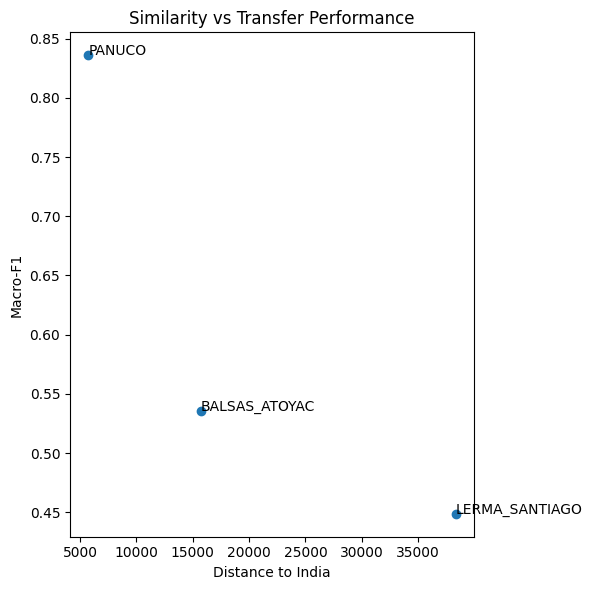

In [61]:
print_section("21. Consolidated Quantitative Validation of Transfer Learning")

df_plot = mexico_basin_results_df.copy()

fig = plt.figure(figsize=(6,6))
plt.scatter(df_plot["Distance_to_India"], df_plot["Macro_F1"])

for i, row in df_plot.iterrows():
    plt.text(row["Distance_to_India"], row["Macro_F1"], row["Basin_Group"])

plt.xlabel("Distance to India")
plt.ylabel("Macro-F1")
plt.title("Similarity vs Transfer Performance")
display_figure(fig)

The negative $R^2$ observed in the Lerma–Santiago basin indicates that the transferred surrogate model performs worse than a baseline mean predictor, providing strong evidence of domain mismatch.

### Interpretation of Cross-Domain Similarity

The similarity analysis performed in this study does not imply that Mexican basins correspond to specific individual rivers within the Indian dataset.

Instead, the Indian dataset represents a composite distribution of multiple river systems, capturing a wide range of physicochemical conditions.

Thus, similarity should be interpreted in terms of feature-space alignment:

$$
P_{Mexico}(X) \approx P_{India}(X)
$$

rather than direct one-to-one correspondence between rivers.

In this context:

- The Pánuco basin lies within the typical range of the Indian feature distribution  
- The Balsas–Atoyac basin partially overlaps but exhibits more extreme values  
- The Lerma–Santiago basin falls outside the learned distribution for several variables  

This explains why transfer learning performance depends on whether the target basin lies within the statistical support of the source domain.